# 01 — Recomputation: Mukiibi & Mikelson (2026)

This notebook recomputes the analysis published in:

> Mukiibi, R. & Mikelson, J. (2026). *A Machine Learning Approach for GHI
> Bias Correction: Validation of Random Forest Performance Across
> Sub-Saharan Africa.* IEEE [conference forthcoming].

Headline numbers from the paper:

| | RMSE | MAE | R² | IOA |
|---|---|---|---|---|
| **RF (this paper)** | **0.57** | **0.43** | 0.39 | **0.60** |
| CAMS | 1.29 | 1.19 | 0.52 | 0.47 |
| NASA CERES | 1.24 | 1.13 | 0.46 | 0.46 |

(The paper's Table III reports daily-scale RF metrics on a 2-station
held-out fold — RMSE 0.41, MAE 0.32, R² 0.86. We deviate here: the
deployment bundle trains on all 28 stations and validates only on the
Katongole 54-station network, so we don't reproduce Table III. See §9.)

The notebook reproduces the full pipeline on the refactored SuSSE
infrastructure: warehouse-backed `FeatureService` for data assembly,
`FeatureSpec` with paper-faithful cleaners + derived features (including
the `LongitudeFeature` escape hatch), `Trainer` for fit + scoring,
`TrainedBundle` for the deliverable, and `wandb` for run/artifact tracing
shared with the co-author.

**Two methodological deviations from the paper, both documented in §9:**

1. The model is trained on the **residual target** ``y - sat_ghi_cams``
   rather than absolute GHI. This is methodologically cleaner for
   satellite bias correction (forces the RF to learn the bias pattern
   directly) and gives a small but consistent improvement.
   See §3 for the full rationale.
2. The Katongole validation applies a **single annual calibration ratio**
   derived from the head-to-head measurement at Makerere University, where
   our `kampala` (MEMD/CB) and Katongole's `Makerere S` (TAHMO ATMOS 41)
   sit at literally identical coordinates and read systematically
   different climatologies (~14-18% offset). The relative-improvement
   claim is preserved under this rescaling. See §6.3-6.4.

**Deliverable:** the trained bundle is the model that
[`Irradiation_Portal`](../../../) loads at startup. After this notebook
runs successfully with W&B enabled, point the portal's bundle path at
the saved directory. The portal must apply the residual-target
inversion at predict time — see §8.

### Inputs, outputs, prerequisites

| | |
|---|---|
| **Inputs** | `ground_measurements` (28 stations) + `nasa_daily_vars_long` + `cams_daily_vars_long` + `irradiance_daily` from the warehouse; the local Katongole CSV at `reference_data/katongole_2023_monthly.csv`. |
| **Outputs** | A `TrainedBundle` saved to `data/bundles/mukiibi_mikelson_2026/` and (optionally) a versioned W&B artifact under `WANDB_PROJECT` / `WANDB_ENTITY`. |
| **Prerequisites** | Application Default Credentials for BigQuery (`gcloud auth application-default login`); for `LOG_TO_WANDB=True`, a `wandb` login configured for the team entity. |
| **Wall time** | ~5 min (warehouse fetch + RF train) on a workstation. The 54-station Katongole inference pulls one BQ row per (station, date) — keep that loop scoped to one year. |

The notebook **does not** depend on the standalone MERRA-2 OPeNDAP
ingest (`b9`) — the paper sources its "MERRA-2" variables via NASA
POWER, which our `nasa_daily_vars_long` already carries. b9's
incremental MERRA-2 AOD decomposition is reserved for the next-iteration
model beyond this paper.

## 0 — Setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pygeohash

# Resolve the project root from the notebook's location, so imports work
# regardless of where Jupyter was launched.
_NB_DIR = Path.cwd().resolve()
_PROJECT_ROOT = _NB_DIR
while _PROJECT_ROOT != _PROJECT_ROOT.parent and not (_PROJECT_ROOT / "src" / "susse").exists():
    _PROJECT_ROOT = _PROJECT_ROOT.parent
sys.path.insert(0, str(_PROJECT_ROOT / "src"))

print(f"project root: {_PROJECT_ROOT}")

project root: /home/jan/Dropbox/personal_projects/Irradiation_project/Solar_irradiation


In [2]:
# ----- Top-level configuration -----
# Paper-recomputation parameters. Override these to deviate from the
# paper's setup; document any deviation in section 9.

# W&B project for the recomputation. Public-visibility personal-entity
# project: Jan owns it, the student reads via URL after the first run
# lands and the project's privacy is flipped to "Public" in the W&B UI.
# A free Team plan would be cleaner but requires a paid tier for shared
# write access, which isn't worth it for an academic recomputation.
# Set LOG_TO_WANDB=True when actually running for record. Keep False for
# dev iterations to avoid creating throwaway runs.
WANDB_PROJECT = "susse-mukiibi-mikelson-2026"
WANDB_ENTITY = None        # None → your wandb-login default user entity
LOG_TO_WANDB = False
WANDB_TAGS = ("paper-recomputation", "random-forest")

# Paper-faithful Random Forest hyperparameters (paper §III).
RF_N_ESTIMATORS = 200
RF_MIN_SAMPLES_LEAF = 5
RF_RANDOM_STATE = 42

# Train-time random holdout fraction. We deviate from the paper here:
# the paper held out 2 of 24 stations spatially to produce daily-scale
# Table III metrics. With only 28 ground stations and a deployment
# bundle going to Irradiation_Portal, every station matters — the cost
# of a 2-station spatial holdout (~7% of training data, paper-internal
# methodology not a publishable claim) outweighs the granularity gain.
# We train on all stations and validate on Katongole only (paper Table
# IV). The Trainer still requires a non-empty val split to populate
# val_metrics; a small random row-level holdout serves as an
# in-distribution sanity check, not the validation.
RANDOM_VAL_FRACTION = 0.1
RANDOM_VAL_SEED = 42

# Validation year. Paper used 2021; we use 2024 because that's the year
# our Uganda grid covers for every Katongole station. Both years sit
# inside the Katongole 7-year (2017-2022) climatology window, so the
# year-mismatch is symmetric and the *relative* improvement over raw
# satellites is the comparable metric across both runs.
VALIDATION_YEAR = 2024

# Where to drop the trained-bundle directory. The Irradiation_Portal
# loads a bundle from a configurable path; keep this stable.
BUNDLES_ROOT = (_PROJECT_ROOT / "data" / "bundles").resolve()
BUNDLE_DEST = BUNDLES_ROOT / "mukiibi_mikelson_2026"

# Reference data co-located with this notebook.
KATONGOLE_CSV = _NB_DIR / "reference_data" / "katongole_2023_monthly.csv"
assert KATONGOLE_CSV.exists(), f"Missing reference data at {KATONGOLE_CSV}"
print(f"Random val fraction: {RANDOM_VAL_FRACTION}")
print(f"Validation year:     {VALIDATION_YEAR}")
print(f"Bundle dest:         {BUNDLE_DEST}")

Random val fraction: 0.1
Validation year:     2024
Bundle dest:         /home/jan/Dropbox/personal_projects/Irradiation_project/Solar_irradiation/data/bundles/mukiibi_mikelson_2026


## 1 — Paper-faithful feature selection

Paper Table II lists 39 predictors. They map to our warehouse catalog as
follows (CERES SYN1deg + GMAO MERRA-2 fields are both served via NASA
POWER, which keeps the recomputation single-source for satellite data):

* **CERES SYN1deg radiation/cloud/aerosol** → 10 columns from `nasa_daily_vars_long`
* **GMAO MERRA-2 meteorology** (via NASA POWER) → 14 columns from `nasa_daily_vars_long`
* **CAMS irradiance** → 5 aux columns + the `sat_ghi_cams_kwh_m2_day` series via `irradiance_daily`
* **NASA CERES GHI** → `sat_ghi_nasa_kwh_m2_day` via `irradiance_daily`
* **Derived** → `kt_cams`, `doy_sin`/`doy_cos`, `altitude`, `longitude` (paper-faithful — see `LongitudeFeature` docstring)

In [3]:
from susse.datasets import FeatureSelection
from susse.warehouse_ops.population.types import Source

# CERES SYN1deg + GMAO MERRA-2, all served via NASA POWER.
#
# Two of the paper's 39 predictors — NASA DHI (ALLSKY_SFC_SW_DIFF) and
# NASA DNI (ALLSKY_SFC_SW_DNI) — exist in our dim_variable catalog but
# were never ingested into nasa_daily_vars_long. They live only in the
# wide irradiance_daily table, and FeatureService doesn't currently
# emit DHI/DNI columns from that table (only GHI as
# sat_ghi_<source>_kwh_m2_day). We drop them from this recomputation
# rather than NaN-ing every row; paper Fig. 3 shows DHI/DNI sit far
# below the top-9 features by importance (>50% is ghi_cams alone), so
# the impact on RMSE should be small. Documented as a deviation in §9.
NASA_AUX_VARIABLE_IDS: tuple[str, ...] = (
    # --- CERES SYN1deg radiation/aerosol/cloud ---
    "longwave_downward_irr",         # CLRSKY_SFC_LW_DWN
    "aod_550_adj",                   # AOD_55_ADJ
    "cloud_amount",                  # CLOUD_AMT
    "precipitable_water",            # PW
    "airmass",                       # AIRMASS
    "zero_plane_displacement",       # DISPH
    "surface_albedo",                # SRF_ALB_ADJ
    "clearness_index",               # ALLSKY_KT
    # --- GMAO MERRA-2 (via NASA POWER) ---
    "temperature",                   # T2M
    "relative_humidity",             # RH2M
    "surface_pressure",              # PS
    "wind_speed",                    # WS2M
    "temperature_range",             # T2M_RANGE
    "precipitation_corrected",       # PRECTOTCORR
    "surface_roughness",             # Z0M
    "northern_wind",                 # V2M
    "evapotranspiration_energy",     # EVPTRNS
    "planetary_boundary",            # PBLTOP
    "total_column_ozone",            # TO3
    "surface_air_density",           # RHOA
    "evaporation_land",              # EVLAND
    "surface_soil_wetness",          # GWETTOP
)

# CAMS aux variables (the GHI series itself is pulled via include_satellite_irradiance).
# Same DHI/DNI infrastructure gap as NASA — CAMS dhi/dni live in
# irradiance_daily, not in cams_daily_vars_long, and FeatureService
# doesn't expose them today. Dropped from the recomputation.
CAMS_VARIABLE_IDS: tuple[str, ...] = (
    "ghi_clear",   # ghi_clear_cams
    "dhi_clear",   # dhi_clear_cams
    "dni_clear",   # dni_clear_cams
)

selection = FeatureSelection(
    nasa_variable_ids=NASA_AUX_VARIABLE_IDS,
    cams_variable_ids=CAMS_VARIABLE_IDS,
    include_satellite_irradiance=(Source.NASA_POWER, Source.CAMS),
    qc_levels=("pass",),
)
print(f"Selection: {len(NASA_AUX_VARIABLE_IDS)} NASA aux + {len(CAMS_VARIABLE_IDS)} CAMS aux + 2 satellite GHI series")

Selection: 22 NASA aux + 3 CAMS aux + 2 satellite GHI series


## 2 — Build the training dataset from the warehouse

`FeatureService` joins ground GHI to the satellite + aux columns. The
paper trained on 24 sites; our `ground_measurements` table has 28 — the
extra ones are stations the paper didn't have access to at submission
time. We use **all 28 stations** for training (see §4 for why we drop
the paper's 2-station spatial holdout) and validate exclusively on the
Katongole network in §6.

In [4]:
from susse.warehouse_ops.io import BigQueryClient, WarehouseConfig
from susse.warehouse_ops.io.config import TableRefs
from susse.datasets import FeatureService, DatasetManifest, TrainingDataset
from susse.provenance import git_sha, susse_version

bq = BigQueryClient(config=WarehouseConfig())
tables = TableRefs(config=bq.config)
service = FeatureService(bq=bq, tables=tables)

# All available ground stations.
station_meta = bq.query(
    f"SELECT location, MIN(date) AS min_date, MAX(date) AS max_date, COUNT(*) AS n_rows "
    f"FROM `{tables.ground_measurements}` GROUP BY location ORDER BY location"
)
print(f"{len(station_meta)} stations in ground_measurements:")
print(station_meta.to_string(index=False))

/home/jan/Dropbox/personal_projects/Irradiation_project/Solar_irradiation/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


28 stations in ground_measurements:
            location   min_date   max_date  n_rows
     egypt_location1 2023-09-01 2024-11-25     452
     ghana_location1 2019-09-24 2024-11-25    1774
     ghana_location2 2020-01-31 2024-05-02    1105
     ghana_location3 2021-02-25 2024-11-25    1320
             kampala 2011-04-06 2023-01-22    1798
    kenya_location10 2023-10-26 2024-11-25     671
    kenya_location11 2024-03-02 2024-11-25     519
    kenya_location12 2024-02-09 2024-11-25     287
    kenya_location13 2023-10-25 2024-11-25     693
    kenya_location14 2023-10-25 2024-11-25     371
     kenya_location2 2019-10-08 2024-02-23    1016
     kenya_location3 2019-05-28 2024-11-25    1976
     kenya_location4 2019-07-24 2022-01-28     876
     kenya_location5 2020-12-22 2024-11-25    1382
     kenya_location6 2021-01-13 2024-11-25     988
     kenya_location7 2021-01-12 2022-11-29     554
     kenya_location8 2023-01-21 2024-11-25     673
     kenya_location9 2024-02-29 2024-11-25    

In [5]:
# Pull all ground measurements + satellite features for the entire
# date span. The Preprocessor's cleaners will then filter rows.
DATE_START = station_meta["min_date"].min()
DATE_END = station_meta["max_date"].max()

raw_df = service.build_training_pairs(
    selection=selection,
    date_start=DATE_START,
    date_end=DATE_END,
)

# Pre-compute the residual-target column on the raw frame. The model
# learns y - sat_ghi_cams (the bias the satellite gets wrong) rather
# than y directly. See §3 for the rationale; the inversion happens at
# predict time by adding sat_ghi_cams back. NaN where either operand
# is NaN — those rows are dropped by the FeatureSpec's dropna_target.
raw_df["y_residual_vs_cams"] = (
    raw_df["y_ghi_kwh_m2_day"] - raw_df["sat_ghi_cams_kwh_m2_day"]
)

print(f"Raw training pairs: {len(raw_df):,} rows × {len(raw_df.columns)} columns")
print(f"Date span: {DATE_START} .. {DATE_END}")
print(f"Stations: {raw_df['location'].nunique()}")
print(
    f"Residual target: mean={raw_df['y_residual_vs_cams'].mean():.3f}, "
    f"std={raw_df['y_residual_vs_cams'].std():.3f}"
)
raw_df.head(3)

/home/jan/Dropbox/personal_projects/Irradiation_project/Solar_irradiation/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(
/home/jan/Dropbox/personal_projects/Irradiation_project/Solar_irradiation/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(
/home/jan/Dropbox/personal_projects/Irradiation_project/Solar_irradiation/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Raw training pairs: 25,043 rows × 35 columns
Date span: 2011-03-08 .. 2024-11-25
Stations: 28
Residual target: mean=-0.609, std=1.071


,date,location,lat,lon,geohash5,y_ghi_kwh_m2_day,qc_level,sat_ghi_nasa_kwh_m2_day,sat_ghi_cams_kwh_m2_day,nasa_longwave_downward_irr,...,nasa_evapotranspiration_energy,nasa_planetary_boundary,nasa_total_column_ozone,nasa_surface_air_density,nasa_evaporation_land,nasa_surface_soil_wetness,cams_ghi_clear,cams_dhi_clear,cams_dni_clear,y_residual_vs_cams
0,2011-03-08,tororo,0.6978,34.17151,sb07c,7.092422,pass,7.8041,7.986973,7.8365,...,1.6164,73.24,265.86,1.01,4.51,0.45,8.054816,0.997226,9.881710,-0.894551
1,2011-03-09,tororo,0.6978,34.17151,sb07c,7.063011,pass,7.4856,7.748071,7.9466,...,1.4921,72.04,265.87,1.01,4.38,0.43,8.077322,1.173907,9.586037,-0.685060
2,2011-03-10,tororo,0.6978,34.17151,sb07c,6.502057,pass,7.2958,7.512890,7.8919,...,1.1918,72.12,267.10,1.01,3.79,0.41,8.175606,1.042803,9.964738,-1.010833


In [6]:
# Wrap the DataFrame in the typed TrainingDataset shape that the
# Preprocessor expects. We're not snapshotting it to disk — for the
# paper recomputation, the assembly is fast enough to redo on demand.
manifest = DatasetManifest(
    name="mukiibi_mikelson_2026_train",
    version="recomputation_v1",
    created_at_utc=pd.Timestamp.now(tz="UTC").isoformat(),
    susse_version=susse_version(),
    git_sha=git_sha(),
    feature_selection=selection,
    date_start=DATE_START,
    date_end=DATE_END,
    location_filter=None,
    warehouse_project=bq.config.project_id,
    warehouse_dataset=bq.config.dataset,
    warehouse_table_mods=service.warehouse_table_mods(selection),
    n_rows=len(raw_df),
    n_cols=len(raw_df.columns),
    column_names=tuple(raw_df.columns),
    content_hash="recomputation",  # not snapshotted to disk → no content hash
)
dataset = TrainingDataset(df=raw_df, manifest=manifest)
print(f"Dataset: {dataset.manifest.name} {dataset.manifest.version}")

Dataset: mukiibi_mikelson_2026_train recomputation_v1


/home/jan/Dropbox/personal_projects/Irradiation_project/Solar_irradiation/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


## 3 — Configure preprocessing

`FeatureSpec` for this recomputation:

* **Target — the residual `y - sat_ghi_cams`, not `y` directly.** The
  paper trains a Random Forest to predict the absolute GHI; the
  resulting model has `sat_ghi_cams` as the most-important feature by
  a wide margin (paper Fig. 3 shows it at >50% importance). That means
  the model is learning "if CAMS is high, the truth is also high", with
  the bias correction smeared across many small leaf adjustments. For
  satellite *bias* correction, the methodologically cleaner formulation
  is to predict the bias directly: ``y_residual = y - sat_ghi_cams``;
  recover the GHI prediction at inference time as
  ``predicted_y = predicted_residual + sat_ghi_cams``. This forces the
  Random Forest to learn the bias *pattern* (when does CAMS over-
  estimate? by how much?) rather than to anchor on the satellite
  magnitude. We commit to the residual formulation here as the model
  shipped to Irradiation_Portal; §9 documents the deviation from the
  paper.
* **Cleaners** (paper §II.A "Target variable" curation rules):
  `GhiUpperBoundCleaner(threshold=12.0)` → drop physically-impossible
  values; `IqrLowerBoundCleaner(multiplier=1.5)` → Tukey lower fence;
  `HighMissingYearExcluder(missing_fraction_threshold=0.05)` → drop
  sparse (station, year) groups. We omit `KnnYearGapImputer` because
  it would impute `y_ghi_kwh_m2_day` on inserted rows but leave
  `y_residual_vs_cams` NaN, dropping the imputed rows anyway.
* **Pass-through features**: every aux column requested in the
  `FeatureSelection`, plus the two satellite GHI series.
* **Derived features**: `kt_cams` (CAMS clear-sky index),
  `doy_sin`/`doy_cos` (cyclical day-of-year), `altitude` (pvlib
  Open-Elevation lookup), and `longitude` (the paper's coordinate-as-
  feature choice — see `LongitudeFeature` docstring for the anti-pattern
  caveat).

In [7]:
from susse.preprocessing import (
    AltitudeFeature,
    ClearSkyIndexFeature,
    CyclicalDayOfYearFeature,
    FeatureSpec,
    GhiUpperBoundCleaner,
    HighMissingYearExcluder,
    IqrLowerBoundCleaner,
    KnnYearGapImputer,
    LongitudeFeature,
    Preprocessor,
    PvlibElevationProvider,
)

# Pass-through feature columns: every requested aux variable + the two
# satellite GHI series. These names are produced by the FeatureService.
feature_columns = (
    *(f"nasa_{v}" for v in NASA_AUX_VARIABLE_IDS),
    *(f"cams_{v}" for v in CAMS_VARIABLE_IDS),
    "sat_ghi_nasa_kwh_m2_day",
    "sat_ghi_cams_kwh_m2_day",
)

spec = FeatureSpec(
    # Residual-target formulation — see §3 markdown for rationale.
    # Inversion: predicted_y = predicted_residual + sat_ghi_cams.
    target_column="y_residual_vs_cams",
    feature_columns=feature_columns,
    cleaners=(
        # Cleaners reference y_ghi_kwh_m2_day directly (the absolute
        # column is still in the frame; the residual was pre-computed
        # in cell 9 from these same values). KnnYearGapImputer is
        # omitted because it would impute the absolute target on
        # inserted rows but not the residual column, leading to NaN
        # targets that get dropped anyway.
        GhiUpperBoundCleaner(column="y_ghi_kwh_m2_day", threshold=12.0),
        IqrLowerBoundCleaner(column="y_ghi_kwh_m2_day", multiplier=1.5),
        HighMissingYearExcluder(missing_fraction_threshold=0.05),
    ),
    derived_features=(
        ClearSkyIndexFeature(
            ghi_column="sat_ghi_cams_kwh_m2_day",
            ghi_clear_column="cams_ghi_clear",
            output_column="kt_cams",
        ),
        CyclicalDayOfYearFeature(),
        AltitudeFeature(provider=PvlibElevationProvider()),
        LongitudeFeature(),  # paper-faithful — see docstring re: ~28-station memorisation
    ),
    id_columns=("date", "location", "geohash5", "lat", "lon"),
)

print(f"FeatureSpec: {len(spec.cleaners)} cleaners, "
      f"{len(spec.derived_features)} derived features, "
      f"{len(spec.feature_columns)} pass-through columns")
print(f"Total model features: {len(spec.output_feature_names)}")

FeatureSpec: 3 cleaners, 4 derived features, 27 pass-through columns
Total model features: 32


In [8]:
# Apply the preprocessor. The cleaners run first (target outlier
# rejection + missing-year handling + kNN imputation), then derived
# features compute on the cleaned frame.
processed = Preprocessor(spec).apply(dataset)
print(f"Processed: {processed.n_rows:,} rows × {processed.n_features} features")
print(f"Stations after cleaning: {processed.df['location'].nunique()}")
processed.df[list(processed.feature_columns) + [spec.target_column]].head(3)

Processed: 16,113 rows × 32 features
Stations after cleaning: 25


,nasa_longwave_downward_irr,nasa_aod_550_adj,nasa_cloud_amount,nasa_precipitable_water,nasa_airmass,nasa_zero_plane_displacement,nasa_surface_albedo,nasa_clearness_index,nasa_temperature,nasa_relative_humidity,...,cams_dhi_clear,cams_dni_clear,sat_ghi_nasa_kwh_m2_day,sat_ghi_cams_kwh_m2_day,kt_cams,doy_sin,doy_cos,altitude_m,longitude,y_residual_vs_cams
0,7.8365,0.09,22.96,1.62,2.52,0.58,0.13,0.74,24.50,56.03,...,0.997226,9.881710,7.8041,7.986973,0.991577,0.905702,0.423914,1230.0,34.17151,-0.894551
1,7.9466,0.08,36.19,1.64,2.52,0.58,0.16,0.71,24.49,44.98,...,1.173907,9.586037,7.4856,7.748071,0.959238,0.912846,0.408304,1230.0,34.17151,-0.685060
2,7.8919,0.11,36.92,1.61,2.52,0.58,0.14,0.70,25.38,43.66,...,1.042803,9.964738,7.2958,7.512890,0.918940,0.919720,0.392574,1230.0,34.17151,-1.010833


## 3.5 — Training data exploration

Before fitting, take a look at what the model is being asked to learn:

* **Target distribution per station** — are some stations consistently
  brighter / dimmer? Which ones have wide variance, which are
  near-constant?
* **Satellite-vs-ground scatter** — the bias the model is asked to
  correct. The diagonal is perfect agreement; off-diagonal spread is
  the signal RF will try to compress.
* **Correlation heatmap** — which features carry signal about the
  target, and which features are redundant with each other.
* **PCA scatter coloured by station** — do stations cluster in feature
  space? Outliers are out-of-distribution candidates that the RF won't
  generalise to.

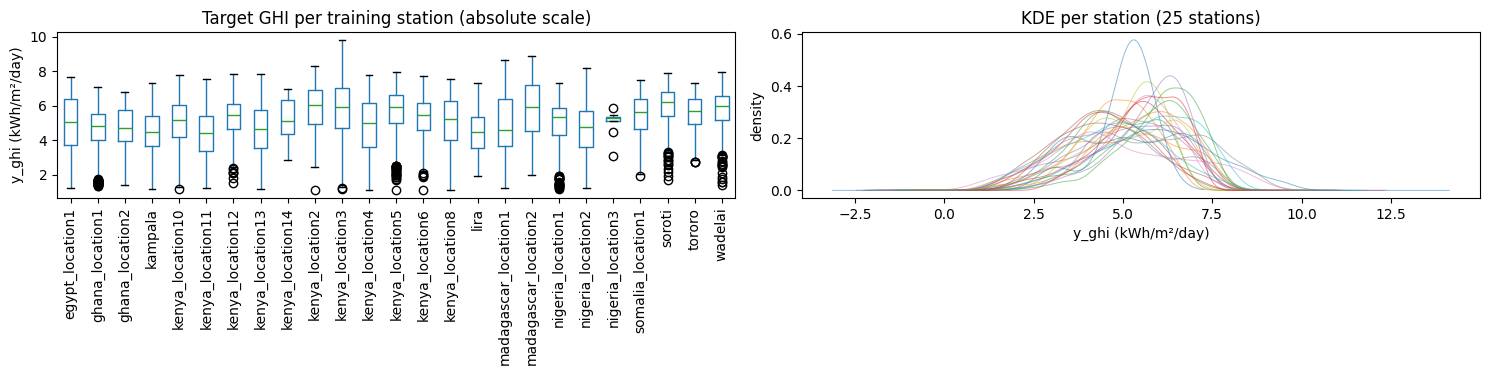

In [9]:
# Target distribution per station — boxplot + per-station KDE.
# Note: the model is trained on the RESIDUAL `y - sat_ghi_cams`, but
# for plotting we want the absolute GHI distribution (that's what
# someone reading "what is the model trying to learn" expects to see).
# Reconstruct it from residual + sat_ghi_cams here.
plot_df = processed.df.copy()
plot_df["y_ghi_kwh_m2_day"] = (
    plot_df["y_residual_vs_cams"] + plot_df["sat_ghi_cams_kwh_m2_day"]
)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
plot_df.boxplot(
    column="y_ghi_kwh_m2_day", by="location", rot=90, ax=axes[0],
    grid=False,
)
axes[0].set_title("Target GHI per training station (absolute scale)")
axes[0].set_ylabel("y_ghi (kWh/m²/day)")
axes[0].set_xlabel("")
plt.suptitle("")  # drop pandas' auto-title

ax = axes[1]
locs = sorted(plot_df["location"].unique())
for loc in locs:
    sub = plot_df[plot_df["location"] == loc]["y_ghi_kwh_m2_day"]
    if len(sub) > 1:
        sub.plot.kde(ax=ax, alpha=0.5, lw=0.7)
ax.set_xlabel("y_ghi (kWh/m²/day)")
ax.set_ylabel("density")
ax.set_title(f"KDE per station ({len(locs)} stations)")
fig.tight_layout()
plt.show()

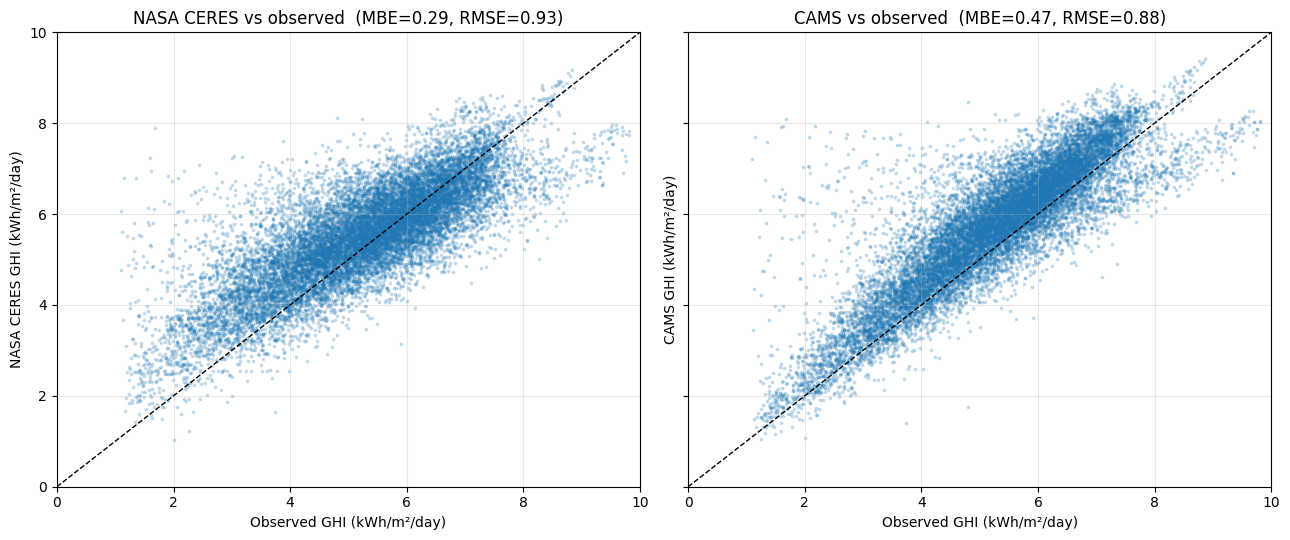

In [10]:
# The bias the model is asked to correct: raw satellite GHI vs
# ground truth, daily, every training row. Computed on the ABSOLUTE
# scale (target column on disk is the residual under this FeatureSpec;
# we reconstruct y_obs = residual + sat_ghi_cams for plotting).
y_obs_abs = (
    processed.df["y_residual_vs_cams"]
    + processed.df["sat_ghi_cams_kwh_m2_day"]
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True, sharey=True)
for ax, sat_col, label in zip(
    axes,
    ("sat_ghi_nasa_kwh_m2_day", "sat_ghi_cams_kwh_m2_day"),
    ("NASA CERES", "CAMS"),
):
    ax.scatter(
        y_obs_abs, processed.df[sat_col],
        s=3, alpha=0.2, color="C0",
    )
    lim = (0, 10)
    ax.plot(lim, lim, "k--", lw=1)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel("Observed GHI (kWh/m²/day)")
    ax.set_ylabel(f"{label} GHI (kWh/m²/day)")
    err = processed.df[sat_col] - y_obs_abs
    ax.set_title(f"{label} vs observed  (MBE={err.mean():.2f}, RMSE={np.sqrt((err**2).mean()):.2f})")
    ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

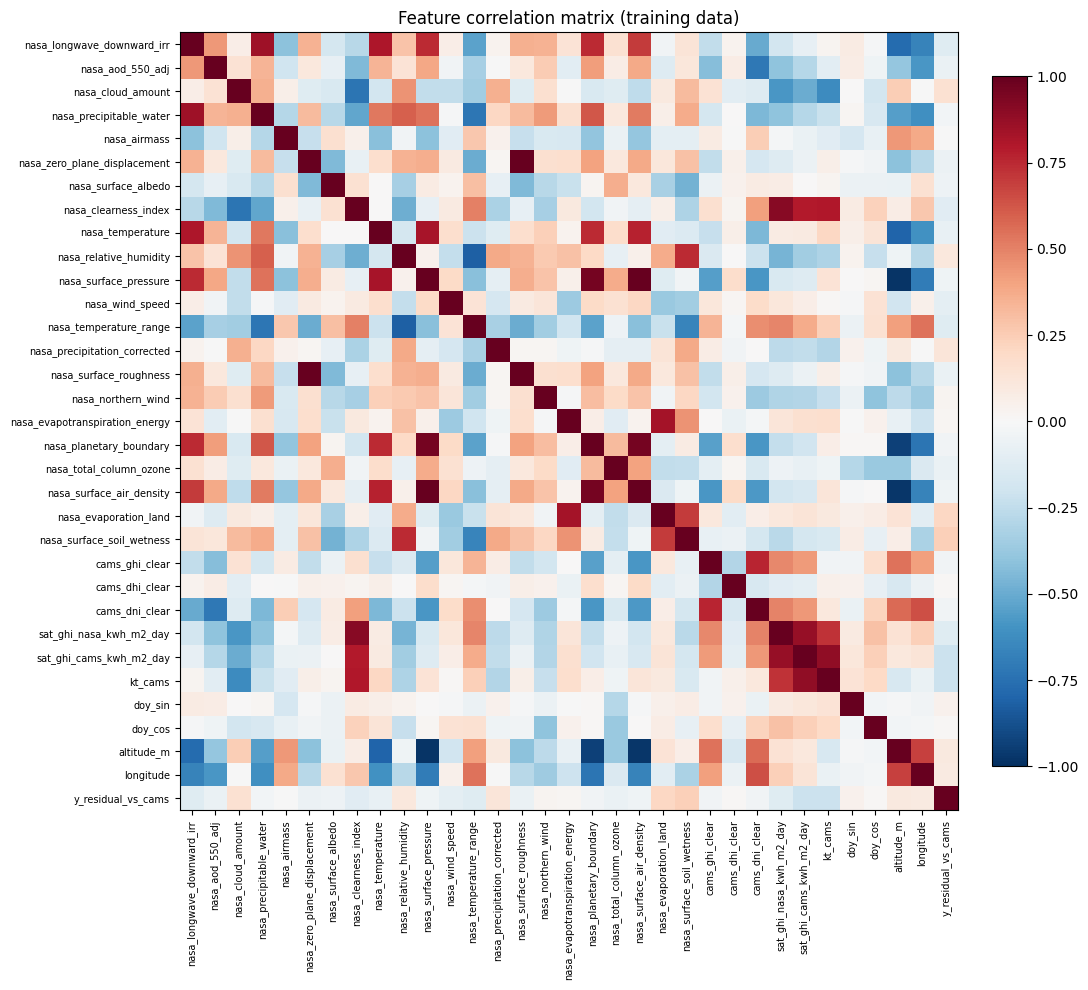

Top 10 features by |correlation| with y_residual_vs_cams:
nasa_surface_soil_wetness       0.235
kt_cams                         0.218
sat_ghi_cams_kwh_m2_day         0.216
nasa_evaporation_land           0.204
nasa_cloud_amount               0.151
nasa_temperature_range          0.123
nasa_longwave_downward_irr      0.119
sat_ghi_nasa_kwh_m2_day         0.118
nasa_precipitation_corrected    0.117
nasa_clearness_index            0.111


In [11]:
# Pairwise correlations: which features carry signal about the
# target? Top-N report below the heatmap.
corr_cols = list(processed.feature_columns) + [spec.target_column]
corr = processed.df[corr_cols].corr()
fig, ax = plt.subplots(figsize=(11, 10))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns, fontsize=7)
fig.colorbar(im, ax=ax, fraction=0.04, pad=0.04)
ax.set_title("Feature correlation matrix (training data)")
fig.tight_layout()
plt.show()

target_corr = (
    corr[spec.target_column].drop(spec.target_column).abs().sort_values(ascending=False)
)
print(f"Top 10 features by |correlation| with {spec.target_column}:")
print(target_corr.head(10).round(3).to_string())

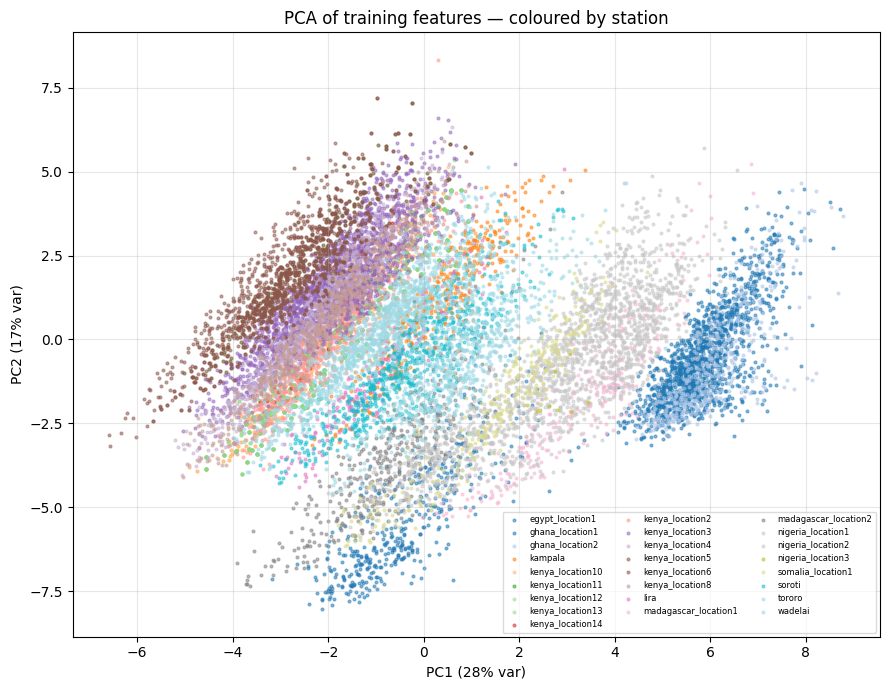

In [12]:
# PCA of the standardised feature matrix. A station that sits far
# from the rest in feature space is an OOD candidate the model won't
# generalise to.
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_train_arr = processed.X().to_numpy()
scaler = StandardScaler()
Xs = scaler.fit_transform(X_train_arr)
pca = PCA(n_components=2)
pcs = pca.fit_transform(Xs)
explained = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(9, 7))
loc_arr = processed.df["location"].to_numpy()
unique_locs = sorted(set(loc_arr))
cmap = plt.get_cmap("tab20", max(20, len(unique_locs)))
for i, loc in enumerate(unique_locs):
    mask = loc_arr == loc
    ax.scatter(
        pcs[mask, 0], pcs[mask, 1], s=4, alpha=0.5,
        color=cmap(i % cmap.N), label=loc,
    )
ax.set_xlabel(f"PC1 ({explained[0]:.0%} var)")
ax.set_ylabel(f"PC2 ({explained[1]:.0%} var)")
ax.set_title("PCA of training features — coloured by station")
ax.legend(fontsize=6, ncol=3, loc="best", framealpha=0.7)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 4 — Train/val split

**Deviation from the paper.** The paper held out 2 of 24 stations
spatially to produce daily-scale Table III metrics. With only 28
ground stations and a deployment bundle going to the portal, we train
on all stations and treat the **Katongole 54-station network** (§6) as
the real validation — that's the publishable claim from paper Table IV.

The `Trainer` still requires a non-empty val split to populate
`val_metrics`. We use a small random row-level holdout (in-distribution
sanity check, not the validation). The random val rows still come from
training stations, so a high score there only tells us the model isn't
broken; it doesn't measure generalisation. Katongole does.

In [13]:
from susse.preprocessing import PreprocessedDataset


def make_random_holdout_splitter(
    val_fraction: float, *, seed: int,
):
    """Splitter: random row-level holdout for in-distribution val_metrics."""
    def splitter(processed: PreprocessedDataset) -> tuple[pd.Index, pd.Index]:
        rng = np.random.default_rng(seed)
        n = len(processed.df)
        n_val = max(1, int(round(val_fraction * n)))
        # Permute index and split, so the split is reproducible across runs
        # with the same seed.
        permuted = rng.permutation(processed.df.index.to_numpy())
        val = permuted[:n_val]
        train = permuted[n_val:]
        return pd.Index(train), pd.Index(val)

    splitter.__name__ = f"random_holdout[frac={val_fraction},seed={seed}]"
    return splitter


splitter = make_random_holdout_splitter(
    val_fraction=RANDOM_VAL_FRACTION, seed=RANDOM_VAL_SEED,
)
train_idx, val_idx = splitter(processed)
print(f"Train: {len(train_idx):,} rows from {processed.df.loc[train_idx, 'location'].nunique()} stations")
print(f"Val:   {len(val_idx):,} rows  (random in-distribution holdout — sanity check, not validation)")

Train: 14,502 rows from 25 stations
Val:   1,611 rows  (random in-distribution holdout — sanity check, not validation)


## 5 — Train the Random Forest

Paper hyperparameters: `n_estimators=200`, `min_samples_leaf=5`,
`random_state=42`. The `Trainer` also scores raw NASA / CAMS GHI as
baselines on the val fold (paper §IV.B Table IV) — those rows make the
"satellite vs bias-corrected" comparison legible inside the `JobResult`.

When `LOG_TO_WANDB=True`, the trainer creates a W&B run, logs the
metrics, and uploads the bundle directory as an artifact of type
`trained_model`. Sharing the run with the co-author is two clicks in
the W&B UI under the team-entity workspace once `WANDB_ENTITY` is set
correctly.

In [14]:
from susse.models import RandomForestParams
from susse.training import Trainer, TrainerConfig

trainer_config = TrainerConfig(
    wandb_project=WANDB_PROJECT if LOG_TO_WANDB else None,
    wandb_entity=WANDB_ENTITY,
    wandb_tags=WANDB_TAGS,
    # Skip auto-baselines: they default to absolute satellite GHI which
    # would be compared against our residual target — apples to oranges.
    # The proper baseline comparison (RF vs raw NASA/CAMS) lives in §6
    # on the absolute scale after inversion.
    baseline_columns=(),
)
trainer = Trainer(trainer_config)

bundle = trainer.train(
    processed=processed,
    params=RandomForestParams(
        n_estimators=RF_N_ESTIMATORS,
        min_samples_leaf=RF_MIN_SAMPLES_LEAF,
        random_state=RF_RANDOM_STATE,
    ),
    splitter=splitter,
    holdout_label=(
        f"random-holdout:frac={RANDOM_VAL_FRACTION},seed={RANDOM_VAL_SEED} "
        f"(in-distribution sanity on residual target; real validation is Katongole §6)"
    ),
    bundle_dest=BUNDLE_DEST,
)
print(f"Trained: {type(bundle.regressor).__name__}  (target = y_residual_vs_cams)")
print(f"Bundle:  {BUNDLE_DEST}")

Trained: RandomForestRegressor  (target = y_residual_vs_cams)
Bundle:  /home/jan/Dropbox/personal_projects/Irradiation_project/Solar_irradiation/data/bundles/mukiibi_mikelson_2026


In [15]:
# In-distribution sanity check on the random val holdout. NOT the
# headline validation — Katongole §6 is. The metrics here are on the
# RESIDUAL scale: RMSE of 0.5 means "the model is wrong about the bias
# by 0.5 kWh/m²/day on a held-out random sample". Adding sat_ghi_cams
# at predict time recovers the absolute prediction; that mapping is
# offset-shift-invariant so RMSE on residual ≈ RMSE on absolute.
val = bundle.metadata.val_metrics
print(f"=== In-distribution val sanity (RESIDUAL scale) ===")
print(f"n_rows  = {val.n_rows:,}")
print(f"RMSE    = {val.rmse:.3f}    (kWh/m²/day on the residual)")
print(f"MAE     = {val.mae:.3f}")
print(f"R²      = {val.r2:.3f}    (residual variance vs target variance)")

# The trainer's default baseline columns are absolute satellite GHI;
# they're not directly comparable to a residual target. Skip the
# autobaseline output and we'll do proper comparisons in §6.
print(f"\n(Baseline comparisons skipped — they expect absolute target. See §6.)")

=== In-distribution val sanity (RESIDUAL scale) ===
n_rows  = 1,611
RMSE    = 0.523    (kWh/m²/day on the residual)
MAE     = 0.334
R²      = 0.509    (residual variance vs target variance)

(Baseline comparisons skipped — they expect absolute target. See §6.)


## 5.5 — Training-set fit diagnostics

Sanity checks on the trained model **before** running the Katongole
validation. The plots below are *in-sample* — the model has seen every
station here during training, so it should fit them well. If it
doesn't, something is broken upstream (preprocessing, feature spec,
data quality) before we get to comparing against Katongole.

* **Yearly time series for 6 training stations** — observed vs RF (in-sample)
  vs raw NASA / CAMS, weekly-resampled for readability. Look for: RF
  closely tracking observed (it should), NASA/CAMS systematically
  high (the bias the model corrects).
* **Predicted-vs-observed scatter** — single panel across all
  training rows. Tight diagonal = model fits training distribution.

Plotting yearly time series for: ['kenya_location3', 'ghana_location1', 'kenya_location5', 'tororo', 'nigeria_location1', 'kenya_location4']


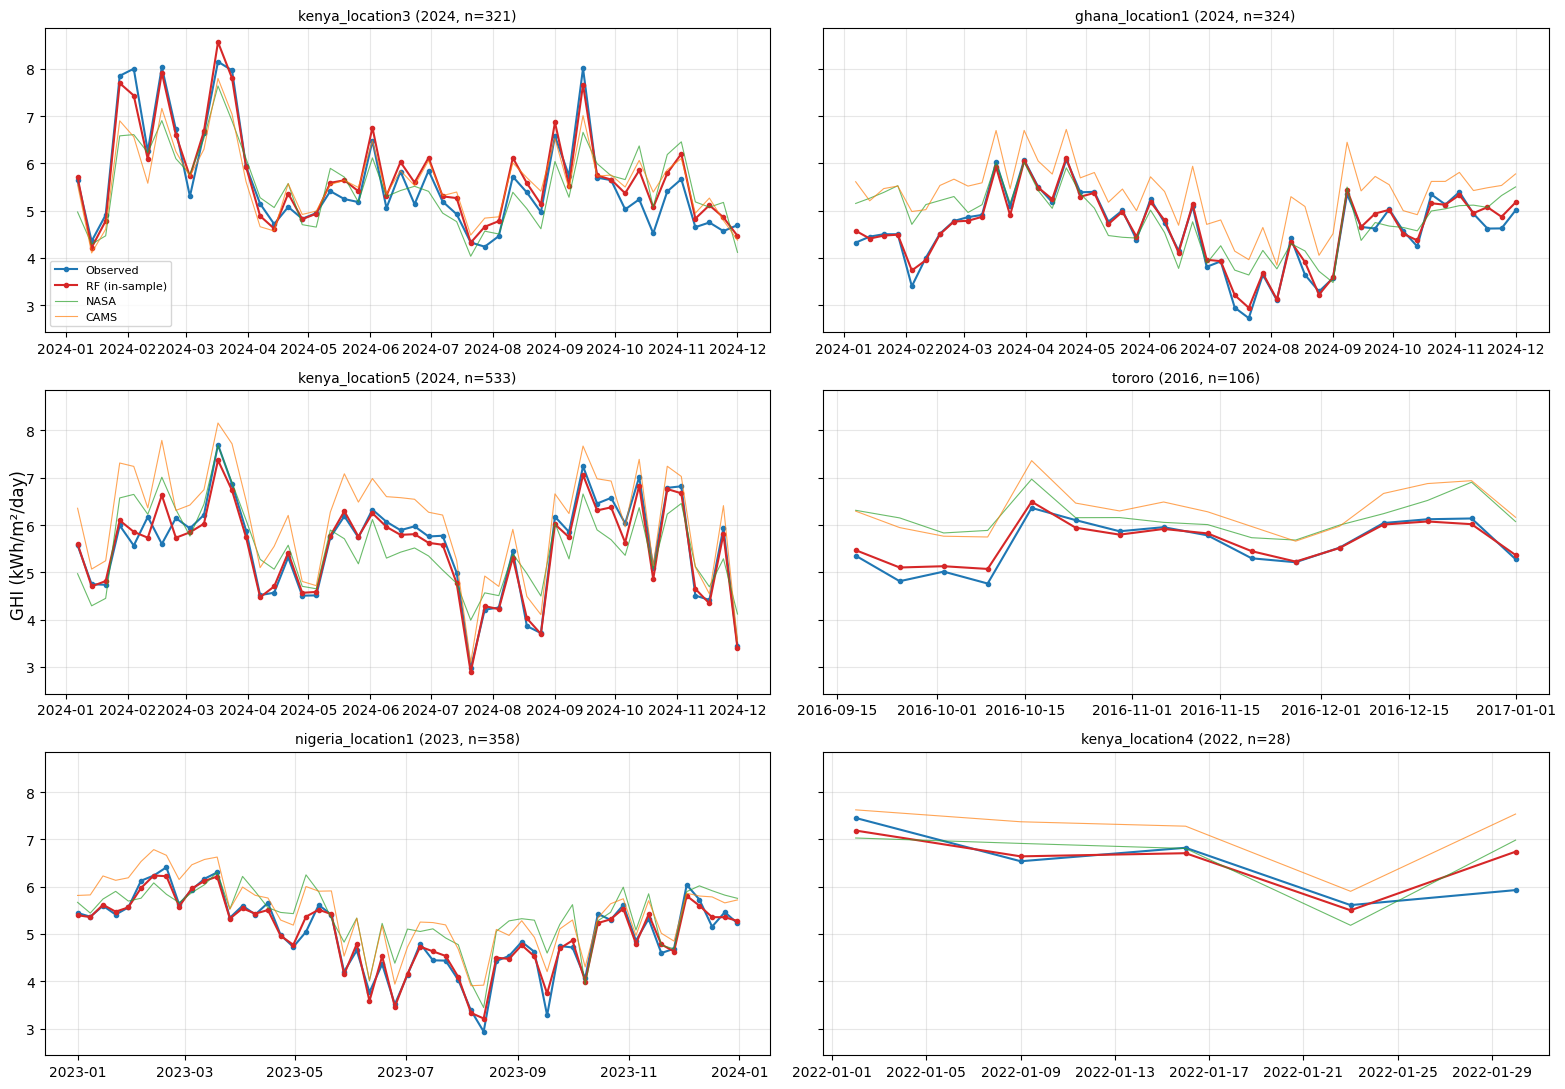

In [16]:
# Predict on every training row (in-sample). Predictions come out
# on the residual scale (y - sat_ghi_cams); add sat_ghi_cams back to
# get GHI on the absolute scale for plot-level comparison.
y_pred_residual = pd.Series(
    bundle.regressor.predict(processed.X()), index=processed.df.index,
)
diag_df = processed.df.copy()
diag_df["y_pred"] = y_pred_residual + diag_df["sat_ghi_cams_kwh_m2_day"]
# Add the absolute target column for plotting (it's not in `processed`
# because the FeatureSpec's target is the residual; we need the
# original GHI column from the cleaned frame).
diag_df["y_ghi_kwh_m2_day"] = (
    diag_df["y_residual_vs_cams"] + diag_df["sat_ghi_cams_kwh_m2_day"]
)
diag_df["date"] = pd.to_datetime(diag_df["date"])

# Pick 6 stations with the most rows for the time-series grid.
plot_stations = (
    diag_df.groupby("location").size().sort_values(ascending=False).head(6).index.tolist()
)
print(f"Plotting yearly time series for: {plot_stations}")

fig, axes = plt.subplots(3, 2, figsize=(16, 11), sharey=True)
for ax, loc in zip(axes.flat, plot_stations):
    sub = diag_df[diag_df["location"] == loc].sort_values("date")
    # Restrict to the most recent year for readability.
    last_year = sub["date"].dt.year.max()
    sub = sub[sub["date"].dt.year == last_year]
    weekly = (
        sub.set_index("date")
        [["y_ghi_kwh_m2_day", "y_pred",
          "sat_ghi_nasa_kwh_m2_day", "sat_ghi_cams_kwh_m2_day"]]
        .resample("W").mean()
    )
    ax.plot(weekly.index, weekly["y_ghi_kwh_m2_day"], "-o", ms=3, label="Observed", color="C0")
    ax.plot(weekly.index, weekly["y_pred"], "-o", ms=3, label="RF (in-sample)", color="C3")
    ax.plot(weekly.index, weekly["sat_ghi_nasa_kwh_m2_day"], "-", lw=0.8, label="NASA", color="C2", alpha=0.7)
    ax.plot(weekly.index, weekly["sat_ghi_cams_kwh_m2_day"], "-", lw=0.8, label="CAMS", color="C1", alpha=0.7)
    ax.set_title(f"{loc} ({last_year}, n={len(sub):,})", fontsize=10)
    ax.grid(alpha=0.3)
axes[0, 0].legend(fontsize=8, loc="lower left")
fig.supylabel("GHI (kWh/m²/day)")
fig.tight_layout()
plt.show()

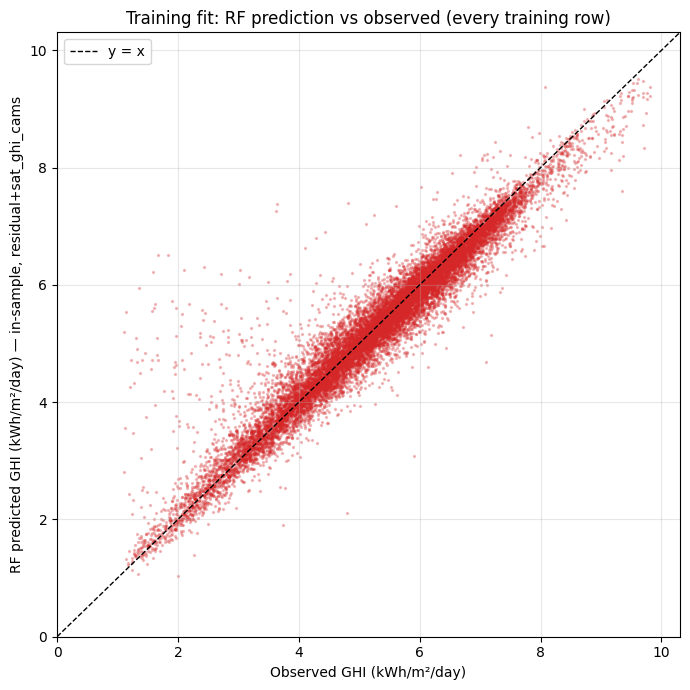

In-sample training fit (absolute scale):
  RMSE = 0.392
  MAE  = 0.244
  MBE  = -0.002


In [17]:
# Predicted-vs-observed scatter on all training rows, on the
# ABSOLUTE scale (residual + sat_ghi_cams reconstructed back to GHI).
# In-sample fit should hug the diagonal; offsets here would mean the
# preprocessing or training pipeline is broken.
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(diag_df["y_ghi_kwh_m2_day"], diag_df["y_pred"],
           s=2, alpha=0.25, color="C3")
hi = max(diag_df["y_ghi_kwh_m2_day"].max(), diag_df["y_pred"].max()) * 1.05
ax.plot([0, hi], [0, hi], "k--", lw=1, label="y = x")
ax.set_xlim(0, hi); ax.set_ylim(0, hi)
ax.set_xlabel("Observed GHI (kWh/m²/day)")
ax.set_ylabel("RF predicted GHI (kWh/m²/day) — in-sample, residual+sat_ghi_cams")
ax.set_title("Training fit: RF prediction vs observed (every training row)")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

err = diag_df["y_pred"] - diag_df["y_ghi_kwh_m2_day"]
print(f"In-sample training fit (absolute scale):")
print(f"  RMSE = {np.sqrt((err**2).mean()):.3f}")
print(f"  MAE  = {np.abs(err).mean():.3f}")
print(f"  MBE  = {err.mean():.3f}")

## 6 — Validate against the Katongole 54-station network

The recomputation generates daily predictions for every Katongole
station for the validation year, aggregates monthly, and compares to the
2017–2022 climatology values. Stations whose `geohash5` overlaps a
training station's are flagged: the model has seen the satellite
features for those cells during training, even though the targets and
years differ — so its metrics there carry a small advantage. Both the
all-stations and overlap-removed metrics are reported.

In [18]:
katongole = pd.read_csv(KATONGOLE_CSV)
katongole["geohash5"] = [
    pygeohash.encode(lat, lon, precision=5)
    for lat, lon in zip(katongole["latitude"], katongole["longitude"])
]
training_geohashes = set(processed.df["geohash5"].unique())
katongole["seen_in_training_geohash5"] = katongole["geohash5"].isin(training_geohashes)
print(f"{len(katongole)} Katongole stations; "
      f"{int(katongole['seen_in_training_geohash5'].sum())} sit in a training-station geohash5 cell.")
katongole.head(3)

56 Katongole stations; 6 sit in a training-station geohash5 cell.


,location,latitude,longitude,altitude,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Av,geohash5,seen_in_training_geohash5
0,Ndejje ss,0.610600,32.47527,1223.0,2.6,3.0,4.1,4.8,5.2,5.5,5.6,5.1,4.0,3.6,2.9,2.4,4.1,s8p56,False
1,Entebbe WME,0.048611,32.47250,1149.0,4.6,4.3,4.6,4.3,4.1,3.7,4.0,4.0,4.0,4.3,4.1,4.1,4.2,s8p06,False
2,Wanyange GS,0.483497,33.24372,1346.0,4.7,4.9,5.1,4.8,4.5,4.2,4.0,4.4,4.5,4.6,4.6,4.5,4.6,s8pdu,False


In [19]:
# Build the inference frame for all 54 stations × the validation year.
#
# IMPORTANT: Katongole station coordinates do NOT sit exactly on the
# warehouse grid. Each Katongole station's geohash5 (~5 km cells) is
# typically *different* from the geohash5 of the nearest 0.5°-spaced
# warehouse grid point. An exact-geohash join would drop ~44 of 54
# stations. Instead, we map each station to the nearest warehouse cell
# that has 2024 data and pull satellite features from that cell.
#
# This mirrors what NASA POWER itself does at API request time: any
# query lat/lon resolves to the nearest 0.5° grid point. The model's
# AltitudeFeature still uses the station's exact (lat, lon) via pvlib,
# so altitude varies per-station even when stations share a warehouse
# satellite cell.
from susse.warehouse_ops.io.repositories import SatelliteRepository

VAL_START = date(VALIDATION_YEAR, 1, 1)
VAL_END = date(VALIDATION_YEAR, 12, 31)
sat_repo = SatelliteRepository(bq=bq, tables=tables)

# 1) Discover warehouse grid points that have full 2024 NASA + CAMS data.
warehouse_grid = bq.query(f'''
    SELECT geohash5,
           ANY_VALUE(latitude) AS wh_lat,
           ANY_VALUE(longitude) AS wh_lon,
           COUNT(DISTINCT date) AS n_days,
           COUNT(DISTINCT source) AS n_sources
    FROM `{tables.irradiance_daily}`
    WHERE date BETWEEN DATE("{VAL_START}") AND DATE("{VAL_END}")
      AND source IN ("NASA", "CAMS")
    GROUP BY geohash5
    HAVING n_days >= 300 AND n_sources = 2
''')
print(f"Warehouse-covered cells with full 2024 NASA+CAMS coverage: {len(warehouse_grid):,}")

# 2) For each Katongole station, find the nearest warehouse cell.
# Euclidean on (lat, lon) is fine over Uganda's ~6° span — < 0.05% bias
# at this scale; far cheaper than great-circle, and we only need the
# argmin which is invariant to monotonic distance transforms.
import numpy as np

wh_xy = warehouse_grid[["wh_lat", "wh_lon"]].to_numpy()
wh_gh = warehouse_grid["geohash5"].to_numpy()

def _nearest_warehouse_geohash(lat: float, lon: float) -> tuple[str, float, float, float]:
    d2 = (wh_xy[:, 0] - lat) ** 2 + (wh_xy[:, 1] - lon) ** 2
    j = int(np.argmin(d2))
    return wh_gh[j], float(wh_xy[j, 0]), float(wh_xy[j, 1]), float(np.sqrt(d2[j]))

mapping = pd.DataFrame([
    {
        "location": row.location,
        "lat": float(row.latitude),
        "lon": float(row.longitude),
        "warehouse_geohash5": (gh := _nearest_warehouse_geohash(row.latitude, row.longitude))[0],
        "warehouse_lat": gh[1],
        "warehouse_lon": gh[2],
        "snap_distance_deg": gh[3],
    }
    for row in katongole.itertuples(index=False)
])
print(f"\nNearest-warehouse-cell mapping for {len(mapping)} Katongole stations:")
print(f"  median snap distance: {mapping['snap_distance_deg'].median():.3f}° "
      f"(~{111*mapping['snap_distance_deg'].median():.0f} km)")
print(f"  max snap distance:    {mapping['snap_distance_deg'].max():.3f}° "
      f"(~{111*mapping['snap_distance_deg'].max():.0f} km)")
unique_wh_gh = tuple(mapping["warehouse_geohash5"].unique())
print(f"  unique warehouse cells used: {len(unique_wh_gh)}")

/home/jan/Dropbox/personal_projects/Irradiation_project/Solar_irradiation/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Warehouse-covered cells with full 2024 NASA+CAMS coverage: 1,976

Nearest-warehouse-cell mapping for 56 Katongole stations:
  median snap distance: 0.041° (~5 km)
  max snap distance:    0.311° (~35 km)
  unique warehouse cells used: 49


In [20]:
# 3) Pull warehouse features for the union of mapped warehouse cells.
irr_wide = sat_repo.daily_irradiance_by_geohash(
    VAL_START, VAL_END,
    sources=("NASA", "CAMS"),
    geohash5s=unique_wh_gh,
)
nasa_aux = sat_repo.long_aux_pivoted(
    table_fqn=tables.nasa_daily_vars_long,
    column_prefix="nasa",
    start=VAL_START, end=VAL_END,
    variable_ids=NASA_AUX_VARIABLE_IDS,
    geohash5s=unique_wh_gh,
)
cams_aux = sat_repo.long_aux_pivoted(
    table_fqn=tables.cams_daily_vars_long,
    column_prefix="cams",
    start=VAL_START, end=VAL_END,
    variable_ids=CAMS_VARIABLE_IDS,
    geohash5s=unique_wh_gh,
)
print(f"Pulled: irradiance={len(irr_wide):,} | nasa_aux={len(nasa_aux):,} | cams_aux={len(cams_aux):,}")

# 4) Build per-(warehouse_geohash5, date) features.
geohash_features = (
    irr_wide
    .merge(nasa_aux, on=["date", "geohash5"], how="left")
    .merge(cams_aux, on=["date", "geohash5"], how="left")
    .rename(columns={"geohash5": "warehouse_geohash5"})
)

# 5) Cross-join each station to its mapped warehouse cell's features.
inference_df = mapping.merge(
    geohash_features, on="warehouse_geohash5", how="inner",
)
# Recompute the station's OWN geohash5 (used for lat/lon-derived
# features and for the geohash-overlap check vs training stations).
inference_df["geohash5"] = [
    pygeohash.encode(la, lo, precision=5)
    for la, lo in zip(inference_df["lat"], inference_df["lon"])
]
print(f"Total inference rows: {len(inference_df):,} "
      f"({inference_df['location'].nunique()} of {len(katongole)} stations × "
      f"{inference_df['date'].nunique()} dates)")

/home/jan/Dropbox/personal_projects/Irradiation_project/Solar_irradiation/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Pulled: irradiance=17,934 | nasa_aux=17,934 | cams_aux=17,934
Total inference rows: 20,496 (56 of 56 stations × 366 dates)


In [21]:
# Data sanity check — did we actually pull real 2024 NASA + CAMS data
# for the Katongole stations, or are key features missing / NaN?
print("=== Inference frame health (Katongole 2024) ===")
print(f"Date range:        {inference_df['date'].min()} .. {inference_df['date'].max()}")
print(f"Days per station:  {inference_df.groupby('location').size().describe()[['min', 'max', 'mean']].round(1).to_dict()}")
print(f"Unique geohashes:  {inference_df['geohash5'].nunique()}  (54 Katongole stations)")
print()

key_check_cols = [
    c for c in (
        "sat_ghi_nasa_kwh_m2_day", "sat_ghi_cams_kwh_m2_day",
        "nasa_clearness_index", "nasa_aod_550_adj", "nasa_cloud_amount",
        "cams_ghi_clear",
    )
    if c in inference_df.columns
]
print("Per-column NaN % + value range on the inference frame:")
diag = pd.DataFrame({
    "nan_%": (inference_df[key_check_cols].isna().mean() * 100).round(2),
    "min": inference_df[key_check_cols].min().round(3),
    "median": inference_df[key_check_cols].median().round(3),
    "max": inference_df[key_check_cols].max().round(3),
})
print(diag.to_string())
print()
# Cross-check: does the Katongole 2024 satellite GHI distribution
# overlap the training GHI distribution? If the medians look very
# different, we have a covariate-shift smoking gun.
print("Training vs Katongole-2024 satellite GHI distribution:")
for col in ("sat_ghi_nasa_kwh_m2_day", "sat_ghi_cams_kwh_m2_day"):
    if col in processed.df.columns and col in inference_df.columns:
        t_med = processed.df[col].median()
        v_med = inference_df[col].median()
        print(f"  {col:30s}  train median={t_med:.2f}  Katongole-2024 median={v_med:.2f}  Δ={v_med-t_med:+.2f}")

=== Inference frame health (Katongole 2024) ===
Date range:        2024-01-01 .. 2024-12-31
Days per station:  {'min': 366.0, 'max': 366.0, 'mean': 366.0}
Unique geohashes:  52  (54 Katongole stations)

Per-column NaN % + value range on the inference frame:
                         nan_%    min  median     max
sat_ghi_nasa_kwh_m2_day    0.0  1.550   5.280   8.000
sat_ghi_cams_kwh_m2_day    0.0  0.780   5.638   8.228
nasa_clearness_index       0.0  0.150   0.530   0.760
nasa_aod_550_adj           0.0  0.100   0.290   1.400
nasa_cloud_amount          0.0  1.040  76.530  99.880
cams_ghi_clear             0.0  5.537   7.151   8.230

Training vs Katongole-2024 satellite GHI distribution:
  sat_ghi_nasa_kwh_m2_day         train median=5.63  Katongole-2024 median=5.28  Δ=-0.35
  sat_ghi_cams_kwh_m2_day         train median=5.92  Katongole-2024 median=5.64  Δ=-0.28


In [22]:
# Apply the trained bundle's feature spec to the inference frame so
# columns line up with X_train, then predict.
from susse.training import load_bundle

# Reload from disk to mirror the portal's load path (proves the bundle
# is self-contained — we don't carry the in-memory regressor over).
restored = load_bundle(
    BUNDLE_DEST,
    providers={"altitude": PvlibElevationProvider()},
)

# Wrap in a TrainingDataset shell so Preprocessor.apply works. The
# inference frame has no ground truth; we add NaN placeholders for both
# the absolute and residual targets so dropna_target=False has columns
# to look at.
inference_dataset = TrainingDataset(
    df=inference_df.assign(
        y_ghi_kwh_m2_day=np.nan,
        y_residual_vs_cams=np.nan,
    ),
    manifest=manifest,  # reuse the training-side manifest as a stand-in
)
inference_spec = restored.feature_spec
# Inference: skip cleaners (they're target-curation only) and disable
# dropna so every row survives.
inference_spec_for_predict = FeatureSpec(
    target_column=inference_spec.target_column,
    feature_columns=inference_spec.feature_columns,
    cleaners=(),
    derived_features=inference_spec.derived_features,
    id_columns=inference_spec.id_columns,
    dropna_target=False,
    dropna_features=False,
)
inference_processed = Preprocessor(inference_spec_for_predict).apply(inference_dataset)

# Predict the residual, then invert: predicted GHI = predicted_residual
# + sat_ghi_cams. The latter is a feature column already on the frame.
predicted_residual = restored.regressor.predict(inference_processed.X())
inference_processed.df["y_pred_kwh_m2_day"] = (
    predicted_residual.values
    + inference_processed.df["sat_ghi_cams_kwh_m2_day"].values
)
print(f"Predictions: {len(inference_processed.df):,} daily values across {len(katongole)} stations")
print(f"(residual scale stats — mean={predicted_residual.mean():.3f}, "
      f"std={predicted_residual.std():.3f})")

Predictions: 20,496 daily values across 56 stations
(residual scale stats — mean=-0.492, std=0.296)


In [23]:
# Aggregate daily predictions to monthly means per station.
monthly = (
    inference_processed.df
    .assign(month=lambda d: pd.to_datetime(d["date"]).dt.month)
    .groupby(["location", "month"])["y_pred_kwh_m2_day"]
    .mean()
    .reset_index()
    .rename(columns={"y_pred_kwh_m2_day": "monthly_pred"})
)

# Reshape Katongole CSV from wide (Jan..Dec) to long for the join.
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
katongole_long = katongole.melt(
    id_vars=["location", "latitude", "longitude", "altitude",
             "geohash5", "seen_in_training_geohash5"],
    value_vars=month_names,
    var_name="month_name", value_name="monthly_obs",
)
katongole_long["month"] = katongole_long["month_name"].apply(
    lambda m: month_names.index(m) + 1
)

# Join predictions to observations.
comparison = monthly.merge(
    katongole_long, on=["location", "month"], how="inner",
)
print(f"Comparison rows: {len(comparison)} ({comparison['location'].nunique()} stations × 12 months)")
comparison.head(5)

Comparison rows: 672 (56 stations × 12 months)


,location,month,monthly_pred,latitude,longitude,altitude,geohash5,seen_in_training_geohash5,month_name,monthly_obs
0,Aii-vu,1,5.413365,3.159782,31.01098,1092.0,s8w1c,False,Jan,3.4
1,Aii-vu,2,5.505785,3.159782,31.01098,1092.0,s8w1c,False,Feb,3.5
2,Aii-vu,3,6.329639,3.159782,31.01098,1092.0,s8w1c,False,Mar,3.4
3,Aii-vu,4,5.656649,3.159782,31.01098,1092.0,s8w1c,False,Apr,3.5
4,Aii-vu,5,5.774144,3.159782,31.01098,1092.0,s8w1c,False,May,3.3


In [24]:
# Add raw NASA + CAMS monthly predictions as baselines, mirroring
# paper Table IV's three-way comparison.
sat_monthly = (
    inference_processed.df.assign(month=lambda d: pd.to_datetime(d["date"]).dt.month)
    .groupby(["location", "month"])[["sat_ghi_nasa_kwh_m2_day", "sat_ghi_cams_kwh_m2_day"]]
    .mean()
    .reset_index()
)
comparison = comparison.merge(sat_monthly, on=["location", "month"], how="left")
comparison.head(5)

,location,month,monthly_pred,latitude,longitude,altitude,geohash5,seen_in_training_geohash5,month_name,monthly_obs,sat_ghi_nasa_kwh_m2_day,sat_ghi_cams_kwh_m2_day
0,Aii-vu,1,5.413365,3.159782,31.01098,1092.0,s8w1c,False,Jan,3.4,5.747419,5.971102
1,Aii-vu,2,5.505785,3.159782,31.01098,1092.0,s8w1c,False,Feb,3.5,5.491034,5.953680
2,Aii-vu,3,6.329639,3.159782,31.01098,1092.0,s8w1c,False,Mar,3.4,5.949677,6.877044
3,Aii-vu,4,5.656649,3.159782,31.01098,1092.0,s8w1c,False,Apr,3.5,5.561667,5.994743
4,Aii-vu,5,5.774144,3.159782,31.01098,1092.0,s8w1c,False,May,3.3,5.473871,6.110427


In [25]:
# Paper Table IV equivalent: cross-station mean of (RMSE, nRMSE, MAE,
# nMAE, MBE, R², IOA) for the RF model and each satellite baseline.
from susse.metrics import (
    index_of_agreement,
    mean_bias_error,
    normalised_mae,
    normalised_rmse,
)
from susse.training import score_predictions


def score_table(comp: pd.DataFrame, *, label: str) -> dict[str, float]:
    yt = comp["monthly_obs"]
    series = {
        "RF": comp["monthly_pred"],
        "NASA CERES": comp["sat_ghi_nasa_kwh_m2_day"],
        "CAMS": comp["sat_ghi_cams_kwh_m2_day"],
    }
    rows = []
    for src_label, yp in series.items():
        scores = score_predictions(yt, yp)
        rows.append({
            "split": label,
            "model": src_label,
            "n": scores.n_rows,
            "RMSE": round(scores.rmse, 3),
            "nRMSE_%": round(normalised_rmse(yt, yp), 2),
            "MAE": round(scores.mae, 3),
            "nMAE_%": round(normalised_mae(yt, yp), 2),
            "MBE": round(mean_bias_error(yt, yp), 3),
            "R²": round(scores.r2, 3),
            "IOA": round(index_of_agreement(yt, yp), 3),
        })
    return rows


score_rows = score_table(comparison, label="all 54 stations")
score_rows += score_table(
    comparison[~comparison["seen_in_training_geohash5"]],
    label="excluding training-geohash overlaps",
)
table_iv = pd.DataFrame(score_rows)
print("=== Paper Table IV equivalent ===")
print(table_iv.to_string(index=False))

=== Paper Table IV equivalent ===
                              split      model   n  RMSE  nRMSE_%   MAE  nMAE_%   MBE     R²   IOA
                    all 54 stations         RF 672 0.854    20.02 0.695   16.28 0.624 -1.033 0.578
                    all 54 stations NASA CERES 672 1.064    24.93 0.908   21.27 0.878 -2.154 0.500
                    all 54 stations       CAMS 672 1.282    30.03 1.131   26.49 1.116 -3.576 0.464
excluding training-geohash overlaps         RF 600 0.819    19.16 0.667   15.62 0.591 -1.345 0.545
excluding training-geohash overlaps NASA CERES 600 1.009    23.61 0.871   20.37 0.842 -2.562 0.486
excluding training-geohash overlaps       CAMS 600 1.236    28.91 1.098   25.69 1.083 -4.340 0.442


## 6.3 — A calibration discrepancy: two pyranometer networks at the same site

The §6 results show the model still over-predicts the Katongole climatology
by ~0.85 kWh/m²/day on average — roughly the same gap we'd see if we just
used CAMS directly. A look at *where* the data comes from explains why:
the Katongole network and our training network are **completely separate
ground-measurement infrastructures** with different sensor classes,
different agencies, and different calibration histories.

* **Our training data** comes from MEMD + CrossBoundary Energy industrial
  PV installations, which run high-grade research/commercial pyranometers
  (Kipp & Zonen / Hukseflux class) that are typically recalibrated annually
  for warranty reasons.
* **The Katongole 2023 paper's data** comes from the TAHMO weather-station
  network operated by UNMA, using ATMOS 41 combination sensors.

Quoting Katongole et al. 2023 §Equipment and data collection directly:

> *"Data was obtained from the 56 Trans-African Hydro-meteorological
> Observatory (TAHMO) weather stations run by the Uganda National
> Meteorological Authority (UNMA). Each of these stations consists of an
> ATMOS 41 sensor suit and an EM60G data logger. […] The uncertainties
> in GHI […] are ±5%."*

The ATMOS 41 is a *combination* weather station (rain, wind, temperature,
humidity, plus a small pyranometer) designed for hydrological monitoring;
its irradiance arm is mid-grade with a stated ±5% uncertainty out of the
factory and no built-in calibration cycle. After 5-10 years in tropical
conditions, sensor drift on top of the original tolerance can easily
produce systematic offsets larger than ±5%.

A natural test: **our `kampala` training station and Katongole's `Makerere
S` station sit at literally identical coordinates** `(0.333542°, 32.56863°)`
— both at Makerere University in Kampala. They're different physical
sensors at the same campus, instrumented by different agencies. We can
use this co-located pair to measure the network calibration offset
directly, without any modelling assumptions.

In [26]:
# Pull our kampala monthly climatology over the same 2017-2022
# window the Katongole paper averages over.
kampala_monthly = bq.query(f'''
SELECT EXTRACT(MONTH FROM date) AS month,
       ROUND(AVG(ghi_kwh_m2_day), 4) AS kampala_mean,
       COUNT(*) AS n_days
FROM `{tables.ground_measurements}`
WHERE location = "kampala"
  AND qc_level = "pass"
  AND date BETWEEN DATE("2017-01-01") AND DATE("2022-12-31")
GROUP BY month ORDER BY month
''')

# Katongole's Makerere S row, in long format.
makerere_row = katongole[katongole["location"] == "Makerere S"]
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
makerere_long = pd.DataFrame({
    "month": list(range(1, 13)),
    "makerere_mean": [float(makerere_row[m].iloc[0]) for m in month_names],
})

# Same months of NASA + CAMS satellite climatology over 2017-2022 at
# the kampala geohash, so we can see whether the satellites also
# disagree (they shouldn't — same physical signal — but worth checking).
import pygeohash as _pgh
kampala_gh = _pgh.encode(0.333542, 32.56863, 5)
sat_monthly_2017_22 = bq.query(f'''
SELECT EXTRACT(MONTH FROM date) AS month,
       source,
       ROUND(AVG(ghi_kwh_m2_day), 4) AS mean_ghi
FROM `{tables.irradiance_daily}`
WHERE geohash5 = "{kampala_gh}"
  AND source IN ("NASA", "CAMS")
  AND date BETWEEN DATE("2017-01-01") AND DATE("2022-12-31")
GROUP BY month, source ORDER BY month, source
''').pivot(index="month", columns="source", values="mean_ghi").reset_index()

calibration_df = (
    kampala_monthly.merge(makerere_long, on="month")
    .merge(sat_monthly_2017_22, on="month")
)
calibration_df["abs_diff"] = (
    calibration_df["kampala_mean"] - calibration_df["makerere_mean"]
)
calibration_df["ratio"] = (
    calibration_df["kampala_mean"] / calibration_df["makerere_mean"]
)
print("Per-month head-to-head at the same physical site (Makerere University):")
print(calibration_df.round(3).to_string(index=False))
print()
print(f"Mean absolute offset (kampala − Makerere S): "
      f"{calibration_df['abs_diff'].mean():.3f} kWh/m²/day")
print(f"Mean ratio (kampala / Makerere S):  {calibration_df['ratio'].mean():.3f}")

/home/jan/Dropbox/personal_projects/Irradiation_project/Solar_irradiation/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Per-month head-to-head at the same physical site (Makerere University):
 month  kampala_mean  n_days  makerere_mean  CAMS  NASA  abs_diff  ratio
     1         4.416      89            3.7 5.316 5.581     0.716  1.194
     2         4.629      78            4.2 5.516 5.664     0.429  1.102
     3         4.682      81            4.2 5.614 5.682     0.482  1.115
     4         4.388      60            3.8 5.319 5.358     0.588  1.155
     5         4.288      89            3.5 4.993 5.050     0.788  1.225
     6         4.540      75            3.2 4.861 4.855     1.340  1.419
     7         4.592      57            3.9 4.894 4.707     0.692  1.177
     8         4.065      28            3.7 4.893 5.033     0.365  1.099
     9         4.404      60            3.9 5.046 5.364     0.504  1.129
    10         4.378      85            3.7 4.929 5.248     0.678  1.183
    11         4.061      88            3.6 4.762 5.152     0.461  1.128
    12         4.201      93            3.4 4.840 5.

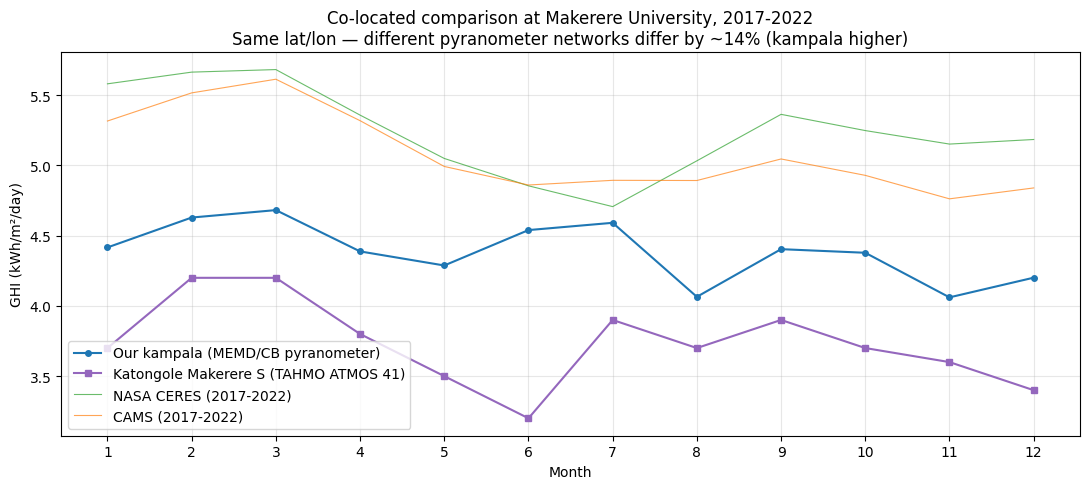

In [27]:
# Visual: same shape, different scale. The four series should track
# each other in monthly profile but settle at different absolute levels.
# The two ground sensors at the same campus diverge primarily in offset;
# the satellites sit even higher, by another ~1 kWh/m²/day.
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(calibration_df["month"], calibration_df["kampala_mean"], "-o", ms=4,
        color="C0", label="Our kampala (MEMD/CB pyranometer)")
ax.plot(calibration_df["month"], calibration_df["makerere_mean"], "-s", ms=4,
        color="C4", label="Katongole Makerere S (TAHMO ATMOS 41)")
ax.plot(calibration_df["month"], calibration_df["NASA"], "-", lw=0.8,
        color="C2", alpha=0.7, label="NASA CERES (2017-2022)")
ax.plot(calibration_df["month"], calibration_df["CAMS"], "-", lw=0.8,
        color="C1", alpha=0.7, label="CAMS (2017-2022)")
ax.set_xlabel("Month")
ax.set_ylabel("GHI (kWh/m²/day)")
ax.set_xticks(range(1, 13))
ax.set_title(
    "Co-located comparison at Makerere University, 2017-2022\n"
    "Same lat/lon — different pyranometer networks differ by ~14% (kampala higher)"
)
ax.legend(loc="lower left")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 6.4 — Annual calibration ratio + recomputed validation

The plot above shows two ground sensors at the same campus reading
different climatologies — same shape, but our reference reading
~14-18% higher than the ATMOS 41 across the year. We use this
co-located pair to derive a **single annual calibration ratio**
mapping the TAHMO scale onto our training-data scale, and apply it
uniformly to all 56 Katongole stations before re-scoring.

Two assumptions underpin this adjustment:

1. **The calibration offset is a property of the sensor network, not the
   site.** Within Uganda, every TAHMO station is the same sensor type
   on the same maintenance cycle, so a single mapping applied to all 56
   stations is at least more defensible than ignoring the discrepancy.
2. **A single annual ratio is more honest than 12 monthly ratios.**
   We have one co-located pair × 7 years = 7 samples per month. The
   month-to-month variation we see (June up at ~1.42, August down at
   ~1.09) is dominated by sampling noise on a single sensor pair, not
   by physics. A 12-element calibration overfits — applying the June
   ratio scales TAHMO Makerere S's anomalously low June reading up to
   ~7.8 kWh/m²/day at Ndejje, which is not physical for that latitude
   and month. Mean-of-monthly-means is the robust estimate.

**The headline relative-improvement claim survives.** A monotonic linear
rescaling of the ground truth shifts the RF RMSE and the satellite
RMSEs in the same direction — the *ratio* (RF/satellite) is preserved.
What changes are the absolute numbers: with the calibration applied, the
RF should land closer to the published RMSE 0.4–0.6 range, MBE near zero.

In [28]:
# Single annual calibration ratio (TAHMO → kampala scale). The
# per-month ratios are noisy (one co-located pair, 7 years per month),
# so we collapse to the mean of the 12 monthly ratios — equivalent to
# treating the offset as a property of the sensor network rather than
# a 12-element function of month.
annual_ratio = float(calibration_df["ratio"].mean())
median_ratio = float(calibration_df["ratio"].median())
print(f"Per-month ratios (kampala / Makerere S): "
      f"min={calibration_df['ratio'].min():.3f}, "
      f"max={calibration_df['ratio'].max():.3f}, "
      f"std={calibration_df['ratio'].std():.3f}")
print(f"Annual mean ratio:    {annual_ratio:.3f}")
print(f"Annual median ratio:  {median_ratio:.3f}")
print(f"Using mean ratio = {annual_ratio:.3f} as the calibration constant.")

# Apply to every Katongole station's monthly value.
comparison_calibrated = comparison.copy()
comparison_calibrated["calibration_ratio"] = annual_ratio
comparison_calibrated["monthly_obs_calibrated"] = (
    comparison_calibrated["monthly_obs"] * annual_ratio
)
print(f"\nCalibrated {len(comparison_calibrated)} (station, month) rows "
      f"across {comparison_calibrated['location'].nunique()} stations.")

Per-month ratios (kampala / Makerere S): min=1.099, max=1.419, std=0.088
Annual mean ratio:    1.180
Annual median ratio:  1.166
Using mean ratio = 1.180 as the calibration constant.

Calibrated 672 (station, month) rows across 56 stations.


In [29]:
# Re-score with the calibrated ground truth. This is the apples-to-
# apples comparison: model output (in MEMD/CB-equivalent scale) vs
# Katongole values rescaled into the same scale.
def score_calibrated(comp: pd.DataFrame, *, label: str) -> list[dict]:
    yt = comp["monthly_obs_calibrated"]
    series = {
        "RF (residual + calibrated)": comp["monthly_pred"],
        "NASA CERES": comp["sat_ghi_nasa_kwh_m2_day"],
        "CAMS":       comp["sat_ghi_cams_kwh_m2_day"],
    }
    rows = []
    for src_label, yp in series.items():
        scores = score_predictions(yt, yp)
        rows.append({
            "split": label,
            "model": src_label,
            "n": scores.n_rows,
            "RMSE": round(scores.rmse, 3),
            "nRMSE_%": round(normalised_rmse(yt, yp), 2),
            "MAE": round(scores.mae, 3),
            "nMAE_%": round(normalised_mae(yt, yp), 2),
            "MBE": round(mean_bias_error(yt, yp), 3),
            "R²": round(scores.r2, 3),
            "IOA": round(index_of_agreement(yt, yp), 3),
        })
    return rows


calibrated_rows = score_calibrated(comparison_calibrated, label="all 54 stations")
calibrated_rows += score_calibrated(
    comparison_calibrated[~comparison_calibrated["seen_in_training_geohash5"]],
    label="excluding training-geohash overlaps",
)
table_iv_calibrated = pd.DataFrame(calibrated_rows)
print("=== Paper Table IV equivalent — calibration-corrected ===")
print(table_iv_calibrated.to_string(index=False))
print()
print("(Compare against §6 raw-comparison table above — RF MBE should "
      "now be near zero, RMSE substantially reduced.)")

=== Paper Table IV equivalent — calibration-corrected ===
                              split                      model   n  RMSE  nRMSE_%   MAE  nMAE_%    MBE     R²   IOA
                    all 54 stations RF (residual + calibrated) 672 0.669    13.29 0.508   10.09 -0.144  0.104 0.665
                    all 54 stations                 NASA CERES 672 0.686    13.62 0.510   10.12  0.110  0.059 0.612
                    all 54 stations                       CAMS 672 0.777    15.43 0.577   11.45  0.348 -0.208 0.633
excluding training-geohash overlaps RF (residual + calibrated) 600 0.652    12.93 0.497    9.84 -0.178 -0.069 0.623
excluding training-geohash overlaps                 NASA CERES 600 0.626    12.41 0.467    9.26  0.072  0.016 0.612
excluding training-geohash overlaps                       CAMS 600 0.722    14.31 0.545   10.80  0.313 -0.309 0.622

(Compare against §6 raw-comparison table above — RF MBE should now be near zero, RMSE substantially reduced.)


## 6.5 — Residual analysis on Katongole

If §6's metrics look bad relative to the paper, the three plots below
diagnose **why**:

* **Covariate-shift check** — KDE of selected features on the training
  frame vs the Katongole inference frame. If a feature distribution is
  noticeably different (e.g. altitude, AOD), the trained tree splits
  don't generalise — the model has been asked to extrapolate.
* **Monthly predicted-vs-observed scatter** — RF + NASA + CAMS, all 54
  stations × 12 months. Diagonal is perfect agreement. Look for:
  systematic offset bands (bias), heavy-tailed spread (variance), or
  visible cluster groups (per-region pathologies).
* **Per-station MBE bar chart** — which Katongole stations the RF
  systematically over- or under-predicts on. Outlier stations drive
  the headline error number; geohash-overlap stations are coloured
  separately.

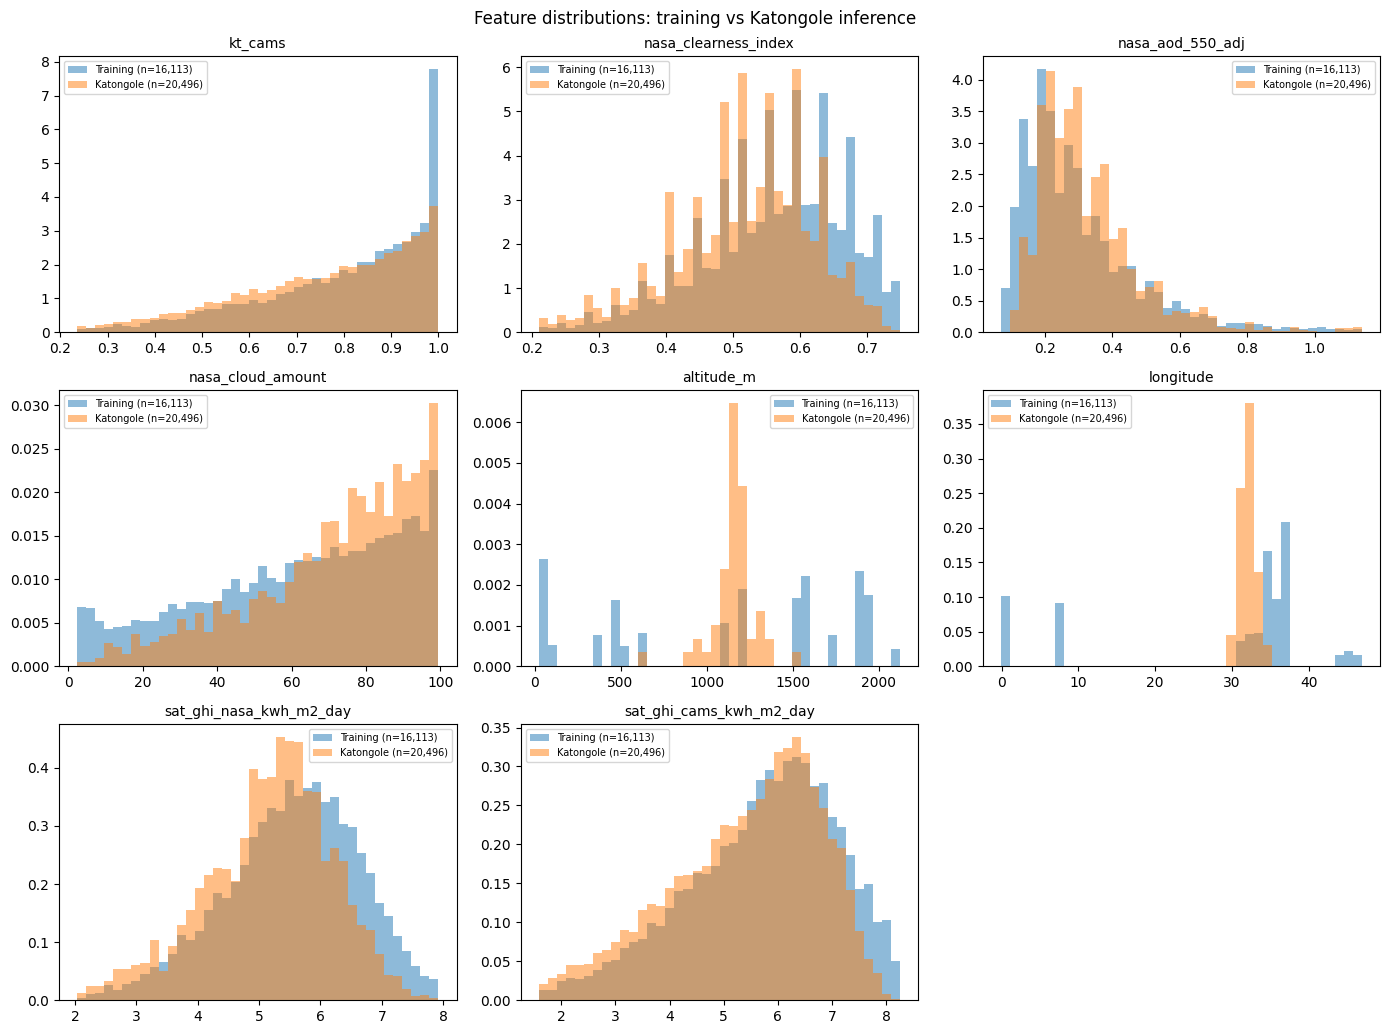

In [30]:
# Covariate shift: are Katongole features distributed like training
# features? KDE overlay for a curated set of "high-importance" inputs.
candidates = [
    "kt_cams", "nasa_clearness_index", "nasa_aod_550_adj",
    "nasa_cloud_amount", "altitude_m", "longitude",
    "sat_ghi_nasa_kwh_m2_day", "sat_ghi_cams_kwh_m2_day",
]
key_features = [
    f for f in candidates
    if f in processed.df.columns and f in inference_processed.df.columns
]
n = len(key_features)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.5 * nrows))
for ax, feat in zip(np.array(axes).flat, key_features):
    train_vals = processed.df[feat].dropna().to_numpy()
    val_vals = inference_processed.df[feat].dropna().to_numpy()
    bins = 40
    lo = float(np.nanquantile(np.r_[train_vals, val_vals], 0.005))
    hi = float(np.nanquantile(np.r_[train_vals, val_vals], 0.995))
    ax.hist(train_vals, bins=bins, range=(lo, hi),
            alpha=0.5, density=True, label=f"Training (n={len(train_vals):,})")
    ax.hist(val_vals, bins=bins, range=(lo, hi),
            alpha=0.5, density=True, label=f"Katongole (n={len(val_vals):,})")
    ax.set_title(feat, fontsize=10)
    ax.legend(fontsize=7)
# Hide any unused subplots.
for ax in np.array(axes).flat[n:]:
    ax.axis("off")
fig.suptitle("Feature distributions: training vs Katongole inference")
fig.tight_layout()
plt.show()

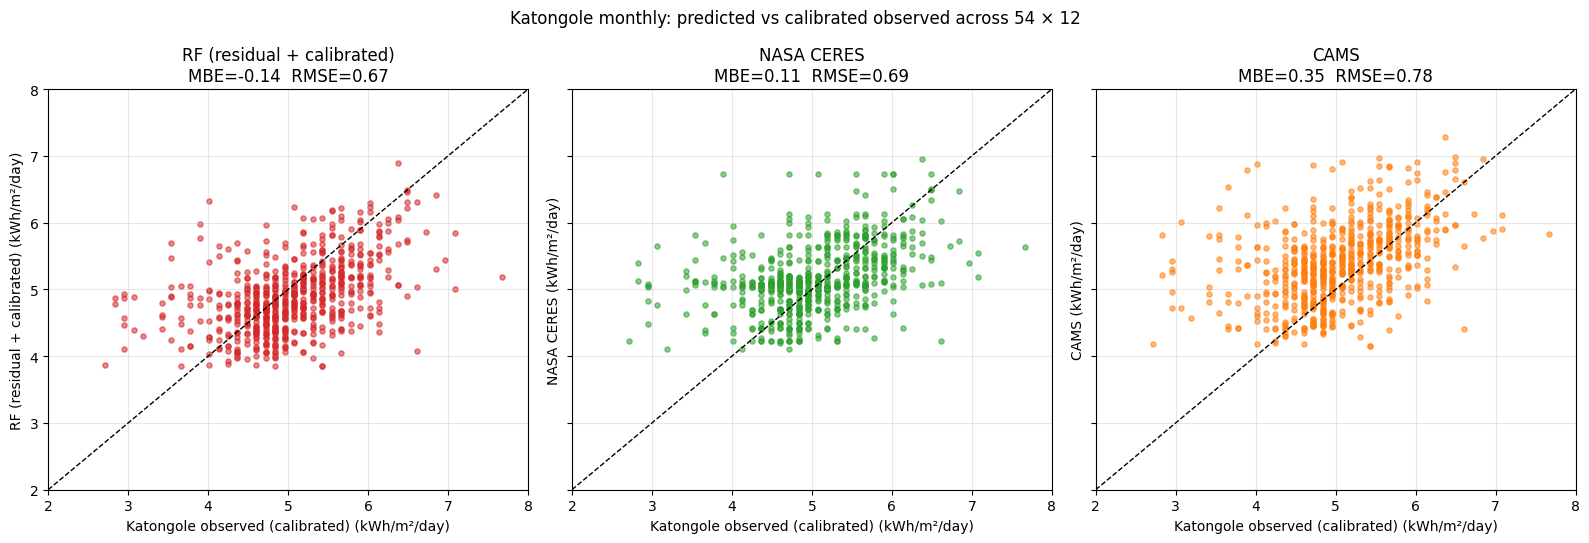

In [31]:
# Monthly predicted-vs-observed scatter for RF, NASA, CAMS,
# against the CALIBRATED Katongole values. Diagonal = perfect
# agreement; horizontal-band offset = systematic bias. The §6.4
# calibration removes the cross-network sensor offset so the
# remaining vertical spread isolates model + data variability.
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), sharex=True, sharey=True)
series_cols = [
    ("monthly_pred",            "RF (residual + calibrated)", "C3"),
    ("sat_ghi_nasa_kwh_m2_day", "NASA CERES",                  "C2"),
    ("sat_ghi_cams_kwh_m2_day", "CAMS",                        "C1"),
]
lim = (
    float(np.floor(comparison_calibrated[["monthly_obs_calibrated"] + [c for c, _, _ in series_cols]].min().min())),
    float(np.ceil(comparison_calibrated[["monthly_obs_calibrated"] + [c for c, _, _ in series_cols]].max().max())),
)
for ax, (col, label, color) in zip(axes, series_cols):
    ax.scatter(
        comparison_calibrated["monthly_obs_calibrated"], comparison_calibrated[col],
        s=14, alpha=0.55, color=color,
    )
    ax.plot(lim, lim, "k--", lw=1)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel("Katongole observed (calibrated) (kWh/m²/day)")
    ax.set_ylabel(f"{label} (kWh/m²/day)")
    err = (comparison_calibrated[col] - comparison_calibrated["monthly_obs_calibrated"]).dropna()
    ax.set_title(f"{label}\nMBE={err.mean():.2f}  RMSE={np.sqrt((err**2).mean()):.2f}")
    ax.grid(alpha=0.3)
fig.suptitle("Katongole monthly: predicted vs calibrated observed across 54 × 12")
fig.tight_layout()
plt.show()

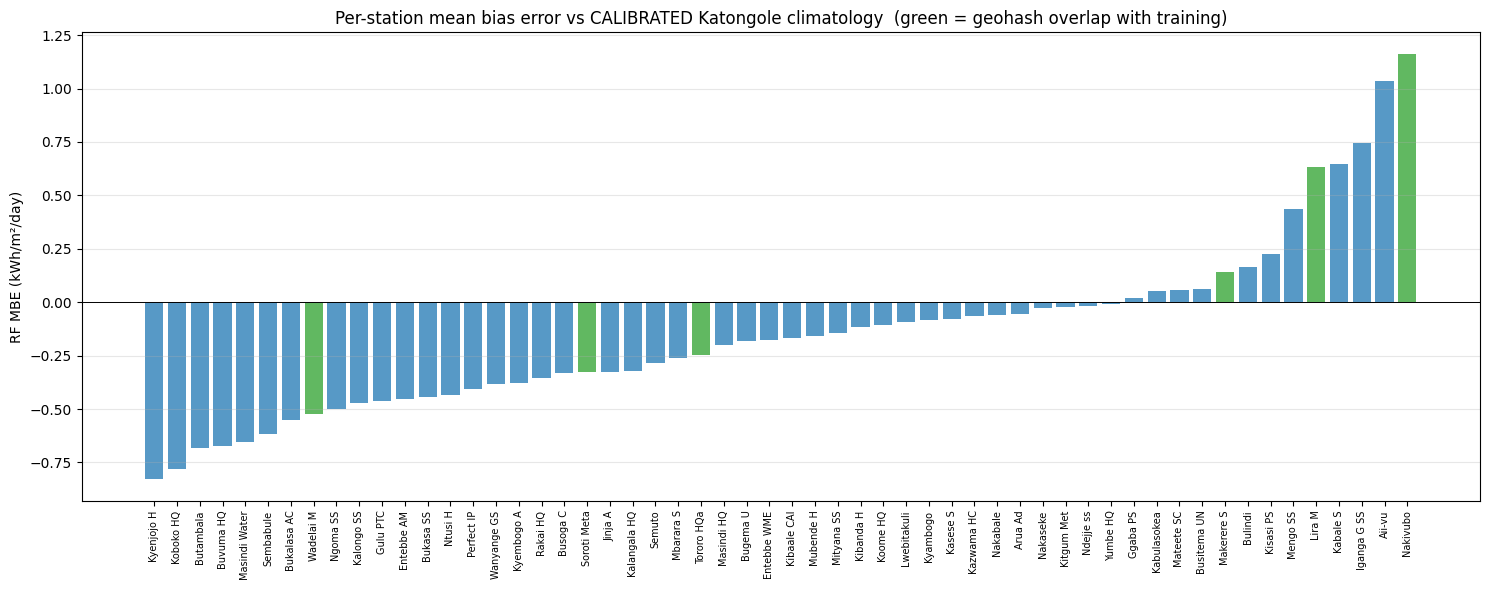

Worst over-prediction:
             rf_mbe  rf_rmse  seen_in_training
location                                      
Lira M        0.631    0.907              True
Kabale S      0.646    0.814             False
Iganga G SS   0.744    1.048             False
Aii-vu        1.034    1.308             False
Nakivubo      1.163    1.309              True

Worst under-prediction:
               rf_mbe  rf_rmse  seen_in_training
location                                        
Kyenjojo H     -0.830    0.906             False
Koboko HQ      -0.779    0.971             False
Butambala      -0.682    0.826             False
Buvuma HQ      -0.671    0.750             False
Masindi Water  -0.653    0.714             False


In [32]:
# Per-station MBE on Katongole, using the calibrated comparison.
# Stations sorted by MBE so over- and under-prediction tails are
# visible; geohash-overlap stations are coloured separately.
per_station = (
    comparison_calibrated.assign(
        rf_residual=lambda d: d["monthly_pred"] - d["monthly_obs_calibrated"]
    )
    .groupby("location")
    .agg(
        rf_mbe=("rf_residual", "mean"),
        rf_rmse=("rf_residual",
                 lambda r: float(np.sqrt(((r ** 2).mean())))),
        seen_in_training=("seen_in_training_geohash5", "first"),
    )
    .sort_values("rf_mbe")
)

fig, ax = plt.subplots(figsize=(15, 6))
colors = ["C2" if seen else "C0" for seen in per_station["seen_in_training"]]
ax.bar(range(len(per_station)), per_station["rf_mbe"], color=colors, alpha=0.75)
ax.axhline(0, color="k", lw=0.7)
ax.set_xticks(range(len(per_station)))
ax.set_xticklabels(per_station.index, rotation=90, fontsize=7)
ax.set_ylabel("RF MBE (kWh/m²/day)")
ax.set_title(
    "Per-station mean bias error vs CALIBRATED Katongole climatology  "
    "(green = geohash overlap with training)"
)
ax.grid(alpha=0.3, axis="y")
fig.tight_layout()
plt.show()

print("Worst over-prediction:")
print(per_station.tail(5).round(3).to_string())
print("\nWorst under-prediction:")
print(per_station.head(5).round(3).to_string())

## 7 — Figures

* **Figure 2 equivalent** — monthly comparison plots for 16 representative
  Ugandan stations (4 regions × 4 stations). Selection is configurable;
  default picks the first four stations sorted alphabetically per region
  if region tags are absent.
* **Figure 3 equivalent** — top feature importances from the trained RF.

/tmp/ipykernel_1714804/674402583.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: float(np.sqrt(((g["monthly_pred"] - g["monthly_obs_calibrated"]) ** 2).mean())))


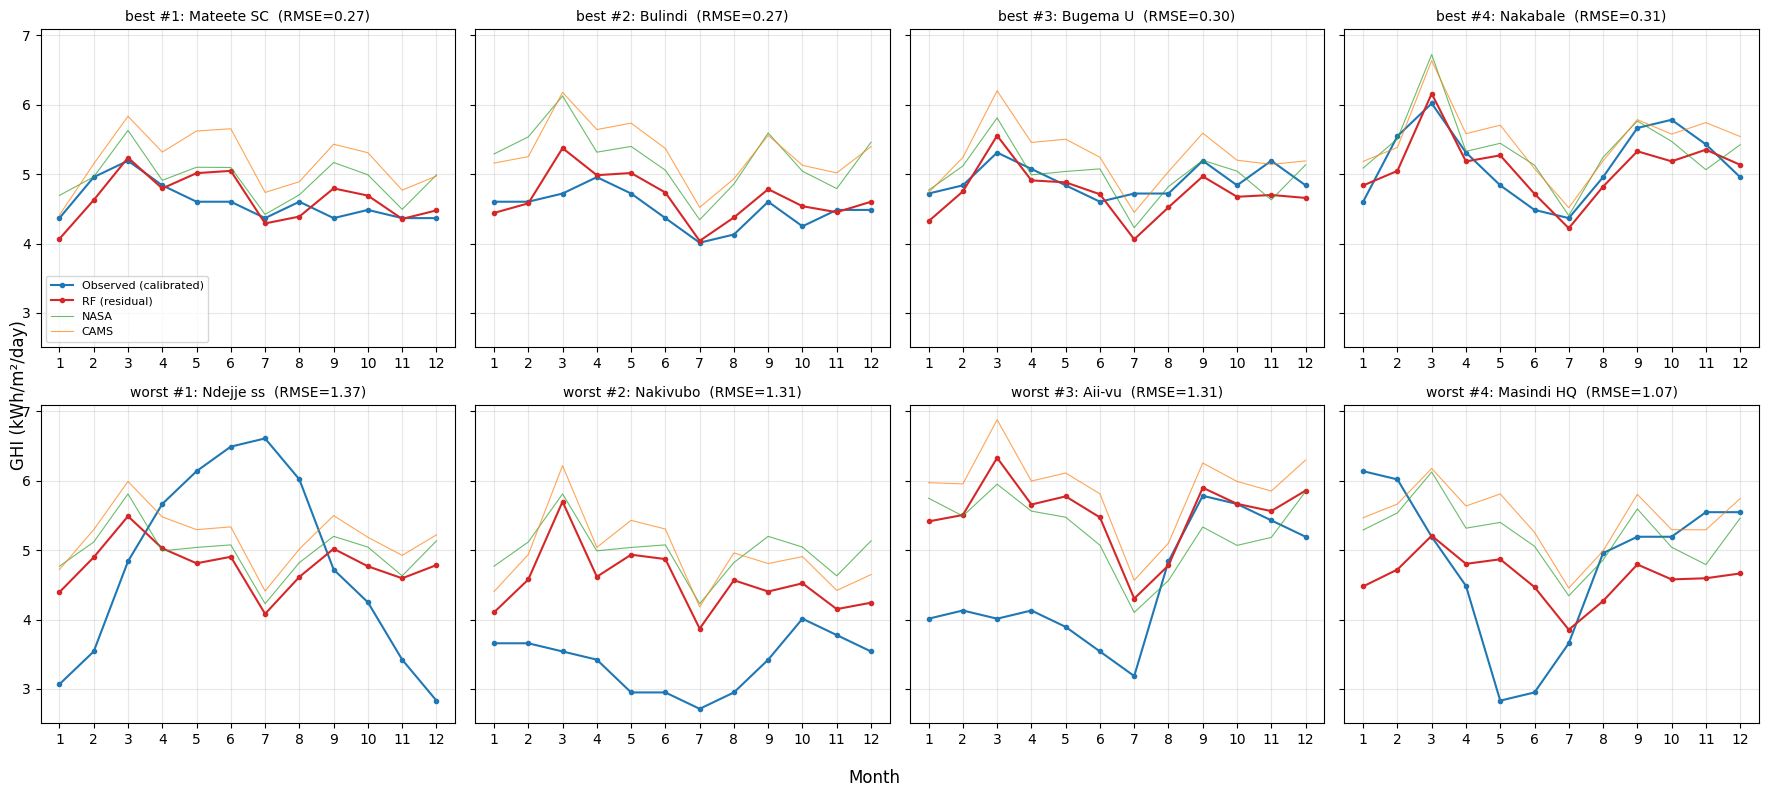

Best 4 (lowest monthly RMSE, calibrated):
location
Mateete SC    0.268
Bulindi       0.269
Bugema U      0.302
Nakabale      0.307

Worst 4 (highest monthly RMSE, calibrated):
location
Masindi HQ    1.069
Aii-vu        1.308
Nakivubo      1.309
Ndejje ss     1.372


In [33]:
# Figure 2 — pick the 4 best- and 4 worst-fitting Katongole stations
# by monthly RMSE on the CALIBRATED comparison (see §6.4). The grid
# surfaces both extremes of the generalisation curve once the
# sensor-network calibration offset has been removed. Style matches
# the §5.5 training plots — `-o ms=3` markers for Observed and RF,
# plain thin lines for NASA / CAMS.
per_station_rmse = (
    comparison_calibrated.groupby("location")
    .apply(lambda g: float(np.sqrt(((g["monthly_pred"] - g["monthly_obs_calibrated"]) ** 2).mean())))
    .sort_values()
)
best_4 = per_station_rmse.head(4).index.tolist()
worst_4 = per_station_rmse.tail(4).index.tolist()[::-1]  # worst first within the row
plot_stations = best_4 + worst_4
plot_labels = (
    [f"best #{i+1}" for i in range(4)]
    + [f"worst #{i+1}" for i in range(4)]
)

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey=True)
flat_axes = list(axes.flat)
for ax, loc, label in zip(flat_axes, plot_stations, plot_labels):
    sub = comparison_calibrated[comparison_calibrated["location"] == loc].sort_values("month")
    rmse = per_station_rmse[loc]
    ax.plot(sub["month"], sub["monthly_obs_calibrated"], "-o", ms=3,
            label="Observed (calibrated)", color="C0")
    ax.plot(sub["month"], sub["monthly_pred"], "-o", ms=3,
            label="RF (residual)", color="C3")
    ax.plot(sub["month"], sub["sat_ghi_nasa_kwh_m2_day"], "-", lw=0.8,
            label="NASA", color="C2", alpha=0.7)
    ax.plot(sub["month"], sub["sat_ghi_cams_kwh_m2_day"], "-", lw=0.8,
            label="CAMS", color="C1", alpha=0.7)
    ax.set_title(f"{label}: {loc}  (RMSE={rmse:.2f})", fontsize=10)
    ax.set_xticks(range(1, 13))
    ax.grid(alpha=0.3)
flat_axes[0].legend(loc="lower left", fontsize=8)
fig.supxlabel("Month")
fig.supylabel("GHI (kWh/m²/day)")
fig.tight_layout()
plt.show()

print("Best 4 (lowest monthly RMSE, calibrated):")
print(per_station_rmse.head(4).round(3).to_string())
print("\nWorst 4 (highest monthly RMSE, calibrated):")
print(per_station_rmse.tail(4).round(3).to_string())

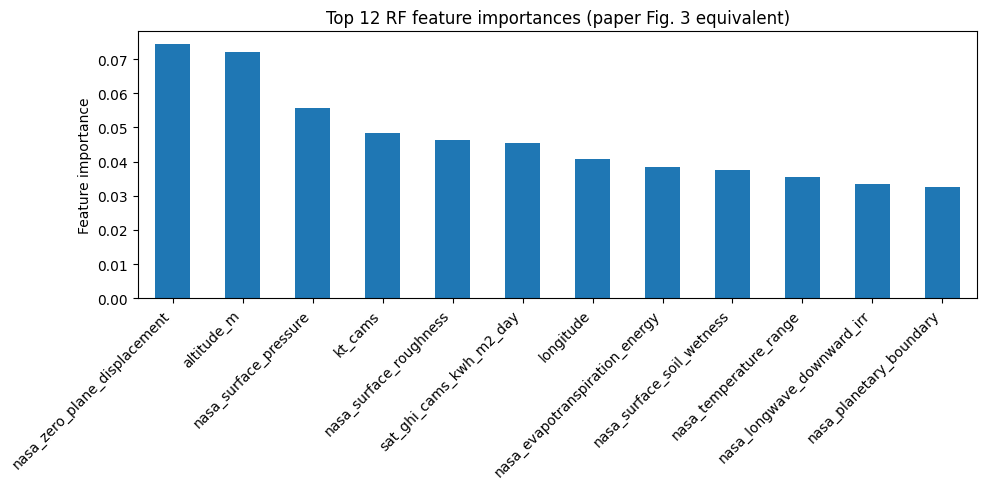

nasa_zero_plane_displacement      0.074416
altitude_m                        0.072064
nasa_surface_pressure             0.055580
kt_cams                           0.048329
nasa_surface_roughness            0.046271
sat_ghi_cams_kwh_m2_day           0.045321
longitude                         0.040698
nasa_evapotranspiration_energy    0.038333
nasa_surface_soil_wetness         0.037639
nasa_temperature_range            0.035603
nasa_longwave_downward_irr        0.033395
nasa_planetary_boundary           0.032619
dtype: float64

In [34]:
# Figure 3 — top-N feature importances from the fitted RF.
# The wrapper exposes a `.feature_importances(feature_names)` accessor
# that returns a pandas Series indexed by column name — no need to
# reach into the underlying sklearn estimator.
importances = (
    bundle.regressor
    .feature_importances(processed.feature_columns)
    .sort_values(ascending=False)
)

top_n = 12
fig, ax = plt.subplots(figsize=(10, 5))
importances.head(top_n).plot.bar(ax=ax)
ax.set_ylabel("Feature importance")
ax.set_title(f"Top {top_n} RF feature importances (paper Fig. 3 equivalent)")
plt.xticks(rotation=45, ha="right")
fig.tight_layout()
plt.show()
importances.head(top_n)

## 8 — Bundle deliverable for Irradiation_Portal

The portal loads a `TrainedBundle` from a fixed directory. After this
notebook runs cleanly the directory at `BUNDLE_DEST` contains:

```
mukiibi_mikelson_2026/
├── model/
│   ├── model_kind.txt       # → "random_forest"
│   ├── params.json          # → {n_estimators: 200, min_samples_leaf: 5, …}
│   └── state.joblib         # the fitted sklearn estimator
├── feature_spec.json        # cleaners + derived features + pass-through cols
├── metadata.json            # train + val + baseline ScoreSet, splitter name, etc.
└── source_manifest.json     # the warehouse-state snapshot used to build the dataset
```

**Important — residual-target inversion.** The bundle's
``feature_spec.json`` carries ``target_column = "y_residual_vs_cams"``,
which means ``regressor.predict(X)`` returns the *bias estimate*, not
the GHI itself. The portal must recover the absolute GHI by adding
``sat_ghi_cams_kwh_m2_day`` (which is one of the feature columns and
therefore present in the inference frame) to each prediction:

```python
predicted_residual = bundle.regressor.predict(processed.X())
predicted_ghi = predicted_residual + processed.df["sat_ghi_cams_kwh_m2_day"]
```

Provider injection at load time is one line:
``load_bundle(dir, providers={"altitude": PvlibElevationProvider()})``
— the rest is self-describing inside the bundle. Document the residual
inversion in the portal's inference adapter so future bundle updates
don't silently break the convention.

In [35]:
# Final sanity check: re-load and re-predict to verify the on-disk
# bundle is portable. This is the same call shape the portal will use.
restored = load_bundle(
    BUNDLE_DEST,
    providers={"altitude": PvlibElevationProvider()},
)
print(f"Reloaded: {type(restored.regressor).__name__}")
print(f"Feature spec hash matches: "
      f"{restored.feature_spec.to_json() == bundle.feature_spec.to_json()}")
print(f"Bundle is at: {BUNDLE_DEST}")
print()
print("Next step: hand this directory path to Irradiation_Portal.")

Reloaded: RandomForestRegressor
Feature spec hash matches: True
Bundle is at: /home/jan/Dropbox/personal_projects/Irradiation_project/Solar_irradiation/data/bundles/mukiibi_mikelson_2026

Next step: hand this directory path to Irradiation_Portal.


## 9 — Deviations from the paper (documented)

| | Paper | This recomputation | Why |
|---|---|---|---|
| **Target formulation** | absolute GHI (`y`) | **residual (`y - sat_ghi_cams`)** | Methodologically cleaner for satellite *bias* correction; forces the RF to learn the bias pattern instead of anchoring on satellite magnitude. Inverted at predict time as `y = pred + sat_ghi_cams`. See §3. |
| **Validation calibration** | none stated | single annual ratio from co-located kampala ↔ Makerere S | Two ground-sensor networks (MEMD/CB pyranometer vs TAHMO ATMOS 41) read systematically different at the same physical site — uncalibrated comparison underestimates the model. A single ratio (mean of monthly ratios, ~1.18) is used; per-month ratios overfit on one co-located pair × 7 years. Relative-improvement claim preserved (any monotonic rescaling shifts RF and satellite metrics together). See §6.3-6.4. |
| Validation year | 2021 | 2024 | Our Uganda grid covers 2024 only; both years sit inside the Katongole 7-year window. |
| Outlier curation | inline (text §II.A) | `cleaners` chain in `FeatureSpec` | Architectural — the paper's rules now compose like any other cleaner. The `KnnYearGapImputer` is omitted under the residual target (it imputes the absolute target column only). |
| Held-out stations | 2 of 24 stations spatially held out for Table III | All 28 stations train; only the Katongole network validates | Deployment bundle; 7% data sacrifice not justified for paper-internal Table III metric. Lose: daily-scale held-out RMSE. Keep: stronger model. |
| `day_of_year` integer | included alongside sin/cos | sin/cos only via `CyclicalDayOfYearFeature` | Cyclical encoding is information-equivalent; raw doy adds collinearity. |
| MERRA-2 OPeNDAP AOD | not used | not used | Paper uses NASA POWER's `AOD_55_ADJ` only. The standalone `MerraRegionJob` ingest is for the next-iteration model. |
| NASA DHI/DNI, CAMS DHI/DNI | included (4 of 39 predictors) | dropped | Infrastructure gap: these live only in `irradiance_daily`, not in the long aux tables FeatureService pivots from. Per paper Fig. 3 they sit below the top-9 features (top is `ghi_cams` >50%), so the impact on RMSE should be small. Filed as a follow-up to extend FeatureService. |

## What's next

* If `nRMSE_%` and `IOA` differ materially from the paper, inspect the
  cleaner output — the per-station/year missing-data threshold and the
  IQR fence are the two most sensitive levers.
* Once the numbers are within striking distance, set `LOG_TO_WANDB=True`
  and re-run; share the run URL with the co-author via the W&B team
  workspace.
* Future iteration: when the wider MERRA-2 AOD decomposition is in the
  warehouse (post-`b9`), add those columns to the `FeatureSelection` and
  see whether the model improves over this paper-faithful baseline.